<a href="https://colab.research.google.com/github/tjayush/Cybersecurity./blob/main/Conversion_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Full CICIDS 2017 Dataset

Setup and Dataset Extraction

In [1]:
import os
import gc
import zipfile
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup paths
ZIP_PATH = '/content/MachineLearningCSV.zip'
EXTRACT_PATH = '/content/cicids_data'

# 1. Extraction logic
if os.path.exists(ZIP_PATH):
    print("Unzipping MachineLearningCSV.zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction complete.")
else:
    print(f"Error: {ZIP_PATH} not found. Please upload the zip to /content/")

# 2. Identify the CSV files

csv_files = glob.glob(os.path.join(EXTRACT_PATH, "MachineLearningCVE", "*.csv"))
print(f"Found {len(csv_files)} CSV files for processing.")

Unzipping MachineLearningCSV.zip...
Extraction complete.
Found 8 CSV files for processing.


Data Cleaning and Merging

In [2]:
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm

def downcast_df(df):
    """Reduces memory footprint by ~50% by converting 64-bit to 32-bit types."""
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns
    df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

    if 'MappedLabel' in df.columns:
        df['MappedLabel'] = df['MappedLabel'].astype('category')
    return df

def clean_and_merge(files, sample_rate=1.0):
    df_list = []


    # Note: Using robust string matching to handle potential double spaces in source CSVs
    label_map = {
        'BENIGN': 'Benign', 'DDoS': 'DDoS', 'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS', 'PortScan': 'Probe',
        'Bot': 'Probe', 'FTP-Patator': 'R2L', 'SSH-Patator': 'R2L',
        'Infiltration': 'U2R', 'Heartbleed': 'DoS',
        'Web Attack Brute Force': 'Web Attack',
        'Web Attack XSS': 'Web Attack',
        'Web Attack Sql Injection': 'Web Attack'
    }

    for file in tqdm(files, desc="Cleaning & Merging (100% Scale)"):

        temp_df = pd.read_csv(file)

        temp_df.columns = temp_df.columns.str.strip()


        temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)

        for col in ['Flow Bytes/s', 'Flow Packets/s']:
            if col in temp_df.columns:
                temp_df[col] = temp_df[col].fillna(temp_df[col].median())


        temp_df.dropna(inplace=True)
        temp_df.drop_duplicates(inplace=True)

        # Sampling: Stratified sample at 100% to keep patterns intact
        temp_df = temp_df.sample(frac=sample_rate, random_state=42)


        temp_df['MappedLabel'] = temp_df['Label'].str.replace(r'\s+', ' ', regex=True).map(label_map).fillna('Benign')
        temp_df.drop('Label', axis=1, inplace=True)


        df_list.append(downcast_df(temp_df))


        del temp_df
        gc.collect()


    full_df = pd.concat(df_list, axis=0, ignore_index=True)


    full_df = downcast_df(full_df)


    del df_list
    gc.collect()

    return full_df

# --- EXECUTION ---
# Execute with sample_rate=1.0 for the full 100% scale
df_master = clean_and_merge(csv_files, sample_rate=1.0)

print(f"\n✅ 100% Dataset Scale loaded successfully.")
print(f"📊 Final Rows: {len(df_master)}")
print(f"💾 Memory Usage: {df_master.memory_usage().sum() / 1024**2:.2f} MB")

Cleaning & Merging (100% Scale): 100%|██████████| 8/8 [00:40<00:00,  5.12s/it]



✅ 100% Dataset Scale loaded successfully.
📊 Final Rows: 2574264
💾 Memory Usage: 768.42 MB


Deep Feature Engineering & 9x9 Image Generation

In [3]:
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler, LabelEncoder
from scipy.cluster.hierarchy import linkage, leaves_list

# --- 1. CORE PREPROCESSING FUNCTION (UPDATED TO 100%) ---
def elite_preprocess(files, sample_rate=1.0):
    df_list = []

    # Dynamic attack mapping to 6 research-standard categories
    attack_map = {
        'BENIGN': 'BENIGN', 'DDoS': 'DDoS', 'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS', 'PortScan': 'Port Scan',
        'Bot': 'Bot', 'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Infiltration': 'Infiltration', 'Web Attack  Brute Force': 'Web Attack',
        'Web Attack  XSS': 'Web Attack', 'Web Attack  Sql Injection': 'Web Attack',
        'Heartbleed': 'Heartbleed'
    }

    for file in tqdm(files, desc="Processing CSVs (100% Scale)"):

        df = pd.read_csv(file)
        df.columns = df.columns.str.strip()

        df.drop_duplicates(inplace=True)
        df.replace([np.inf, -np.inf], np.nan, inplace=True)


        if 'Flow Bytes/s' in df.columns:
            df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(df['Flow Bytes/s'].median())
        if 'Flow Packets/s' in df.columns:
            df['Flow Packets/s'] = df['Flow Packets/s'].fillna(df['Flow Packets/s'].median())


        df = df.sample(frac=sample_rate, random_state=42)


        df['Attack Type'] = df['Label'].map(attack_map).fillna('BENIGN')
        df.drop('Label', axis=1, inplace=True)


        fcols = df.select_dtypes('float').columns
        df[fcols] = df[fcols].astype('float32')
        icols = df.select_dtypes('integer').columns
        df[icols] = df[icols].astype('int32')

        df_list.append(df)
        gc.collect()

    return pd.concat(df_list, axis=0, ignore_index=True)


df_master = elite_preprocess(csv_files, sample_rate=1.0)
print(f"✅ Data Loaded. Samples: {len(df_master)}")

features = df_master.drop('Attack Type', axis=1)
features = features.loc[:, features.std() > 0]

print("🔄 Calculating Hierarchical Correlation (Grouping features)...")
corr = features.corr().fillna(0).values
Z = linkage(corr, 'ward')
new_order = leaves_list(Z)
ordered_features = features.iloc[:, new_order]

print("⚖️ Applying Quantile Mapping (Normalizing distribution)...")
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                         subsample=100000, random_state=42)
mm = MinMaxScaler()


scaled_data = mm.fit_transform(qt.fit_transform(ordered_features))


pad_size = 81 - scaled_data.shape[1]
padding = np.zeros((scaled_data.shape[0], pad_size), dtype='float32')
images_9x9 = np.hstack([scaled_data, padding]).reshape(-1, 9, 9)


le = LabelEncoder()
y_encoded = le.fit_transform(df_master['Attack Type'])

gc.collect()

print(f"\n✅ 100% PREPROCESSING COMPLETE")
print(f"🔹 Tabular Input Shape: {scaled_data.shape[1]}")
print(f"🔹 Image Input Shape: {images_9x9.shape[1]}x{images_9x9.shape[2]}")
print(f"🔹 Total Classes Found: {len(le.classes_)} ({list(le.classes_)})")

Processing CSVs (100% Scale): 100%|██████████| 8/8 [00:37<00:00,  4.72s/it]


✅ Data Loaded. Samples: 2574264
🔄 Calculating Hierarchical Correlation (Grouping features)...
⚖️ Applying Quantile Mapping (Normalizing distribution)...

✅ 100% PREPROCESSING COMPLETE
🔹 Tabular Input Shape: 70
🔹 Image Input Shape: 9x9
🔹 Total Classes Found: 8 (['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'Port Scan'])


Correlation Structural Analysis: From Tabular Noise to Visual Texture

📊 Generating correlation heatmaps...


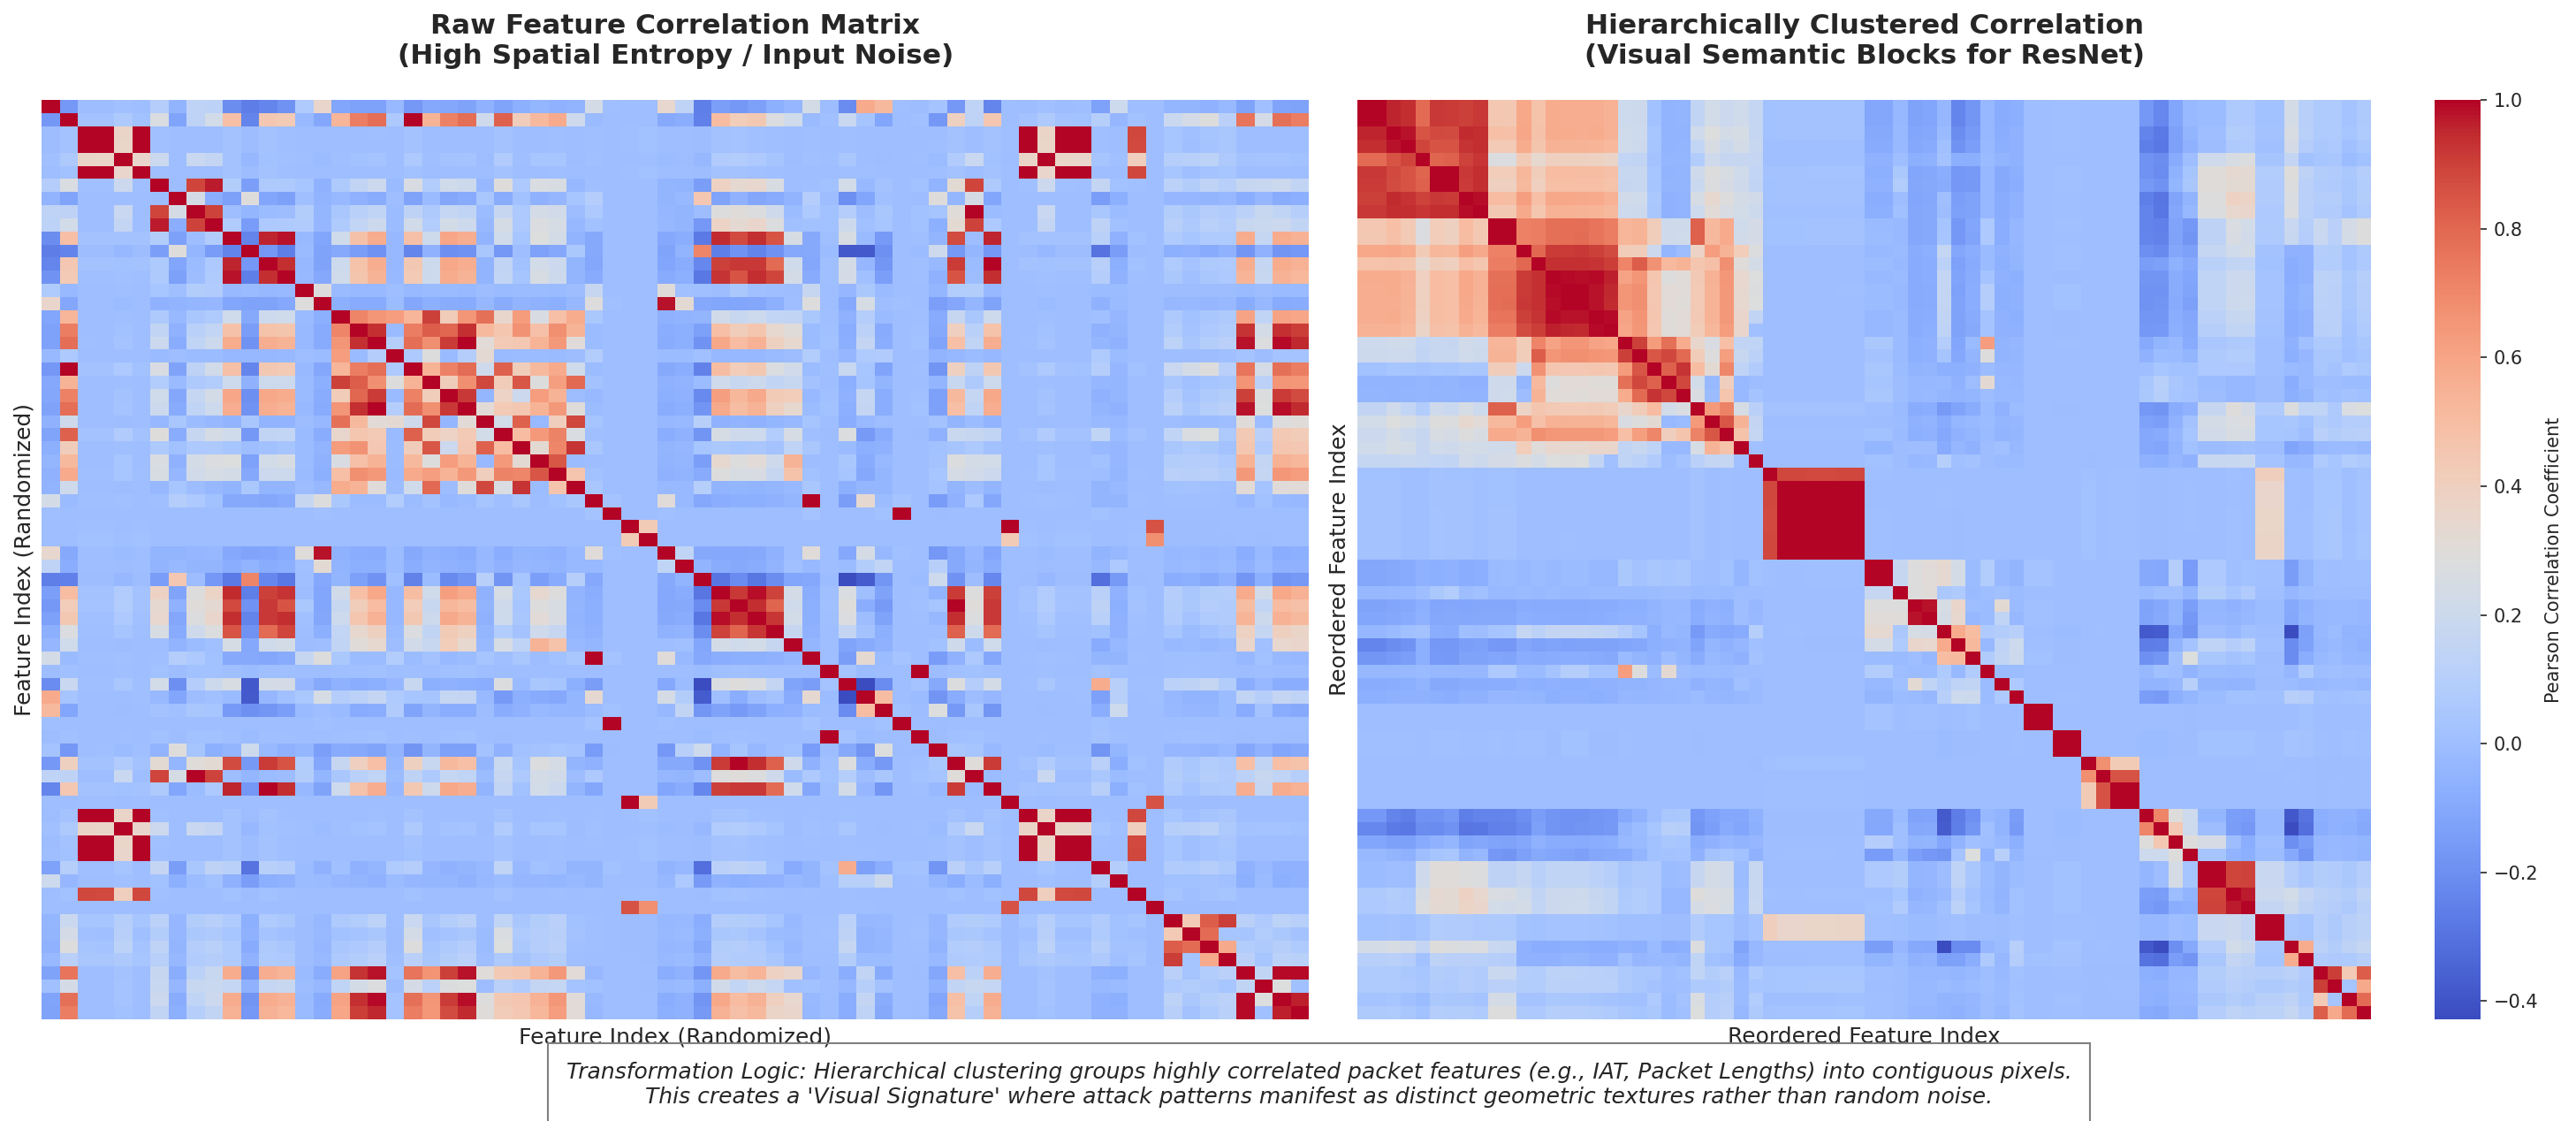

✅ Visualization generated. Reordering has successfully concentrated 70 features into logical clusters.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


plt.rcParams['figure.dpi'] = 150
sns.set_style("white")


print("📊 Generating correlation heatmaps...")


original_corr = features.corr().fillna(0)
reordered_corr = ordered_features.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))


sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"✅ Visualization generated. Reordering has successfully concentrated {len(features.columns)} features into logical clusters.")

---------------- 1. Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv-------------

1. Targeted Data Loading & Robust Cleaning

In [5]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip().replace({'Web Attack  Brute Force': 'Web Attack - Brute Force'})

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Raw Flow Shape: 225,745 Rows | 79 Columns
Post-Sanitization Volume: 223,112 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'DDoS']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [6]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [7]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

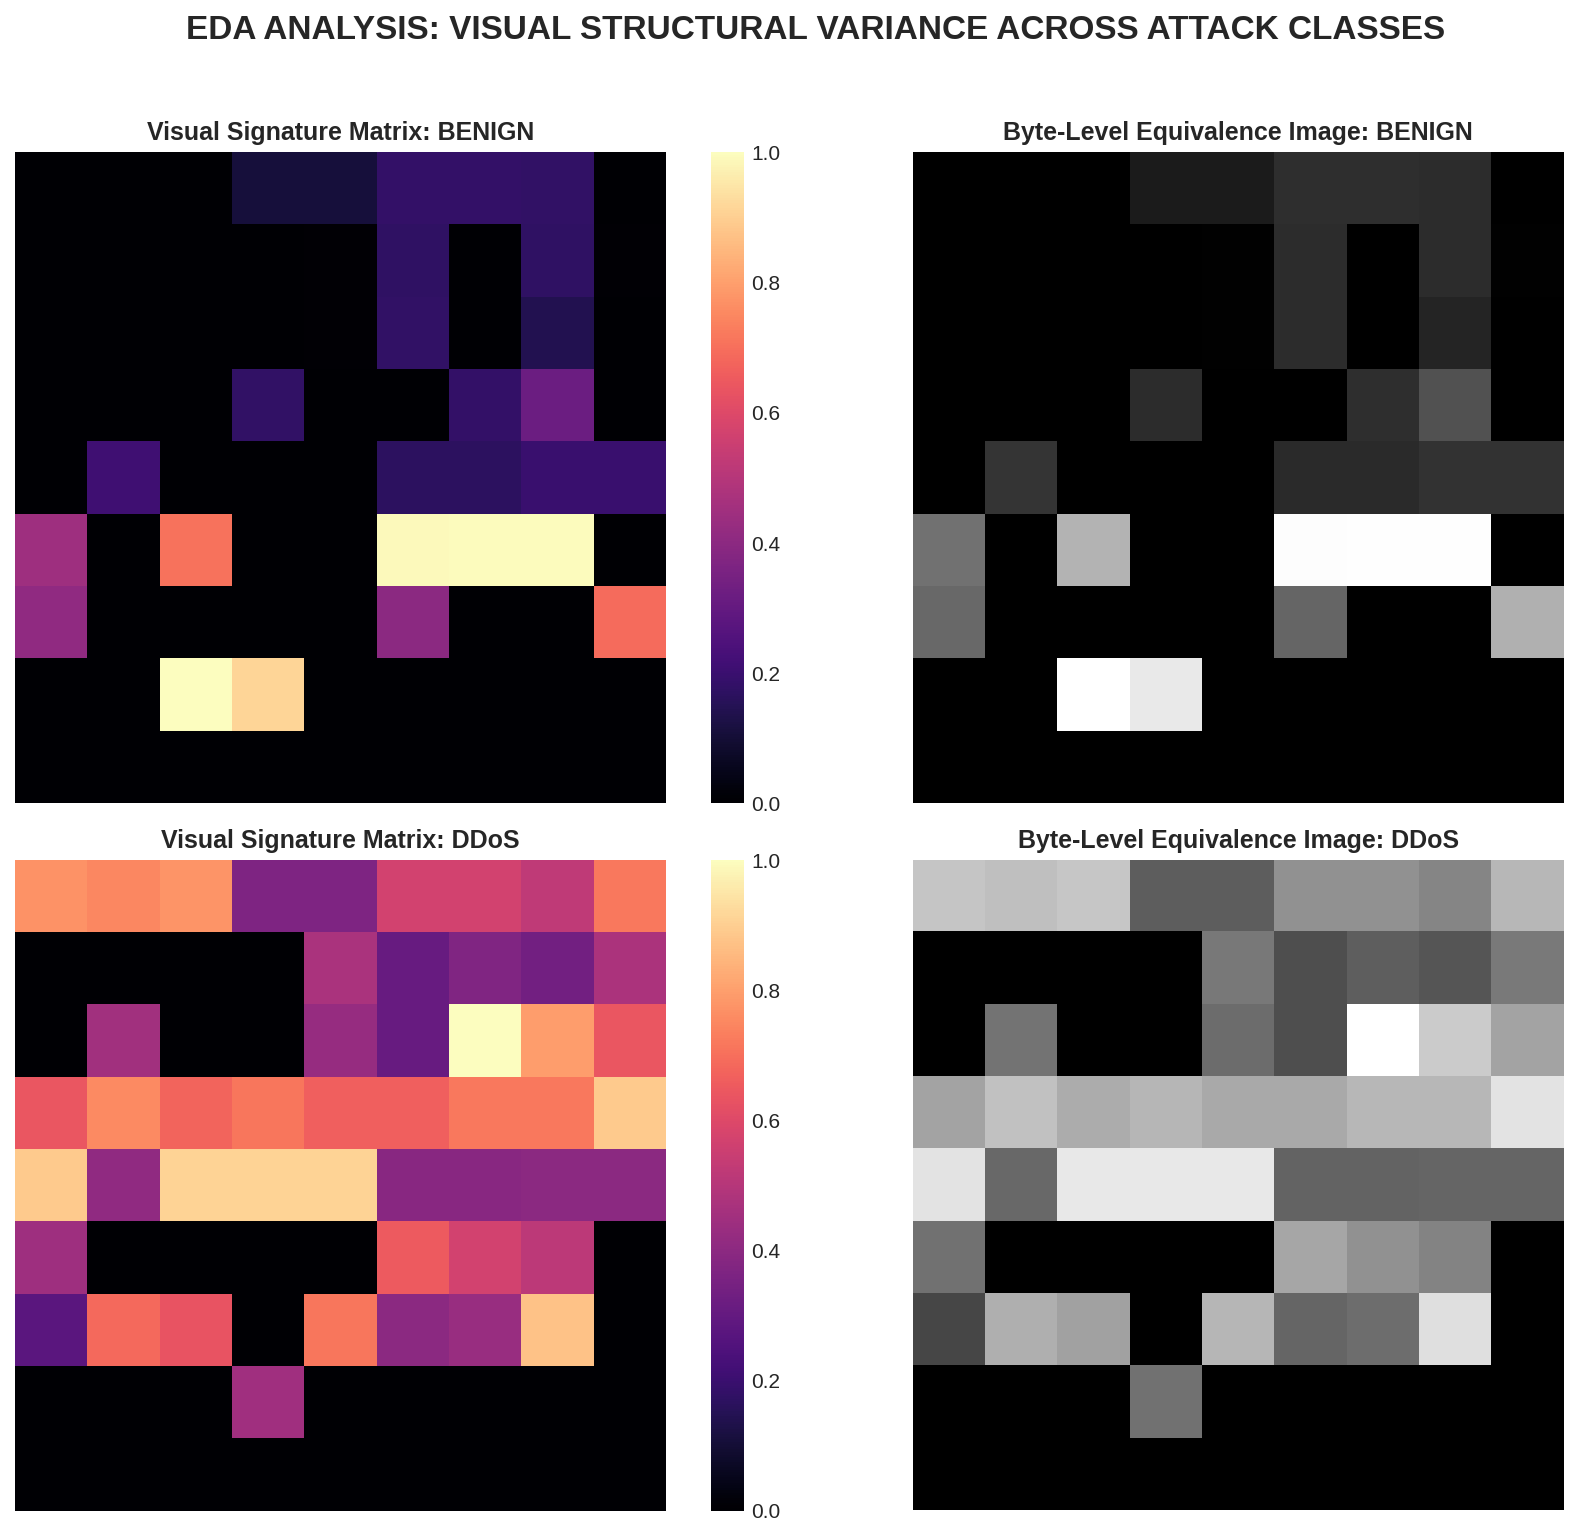

In [8]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


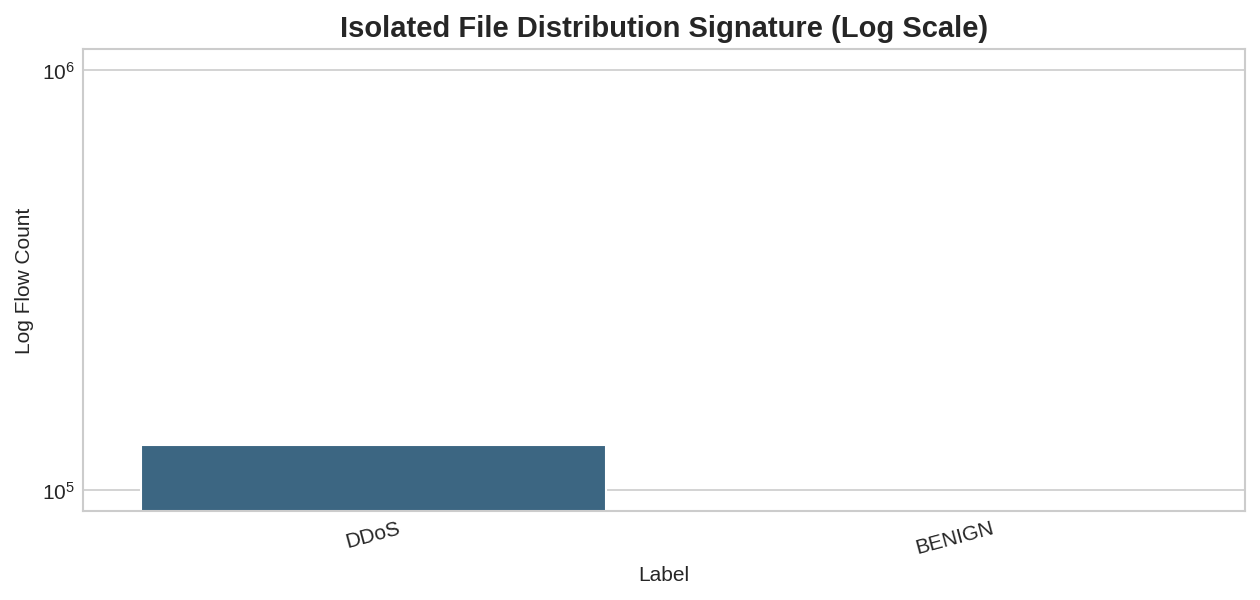

📝 Current Sub-split Frequency Index:
 🔹 DDoS            : 128,016 flows (57.38%)
 🔹 BENIGN          : 95,096 flows (42.62%)


In [9]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("📝 Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

Generating comparative visualization plots...


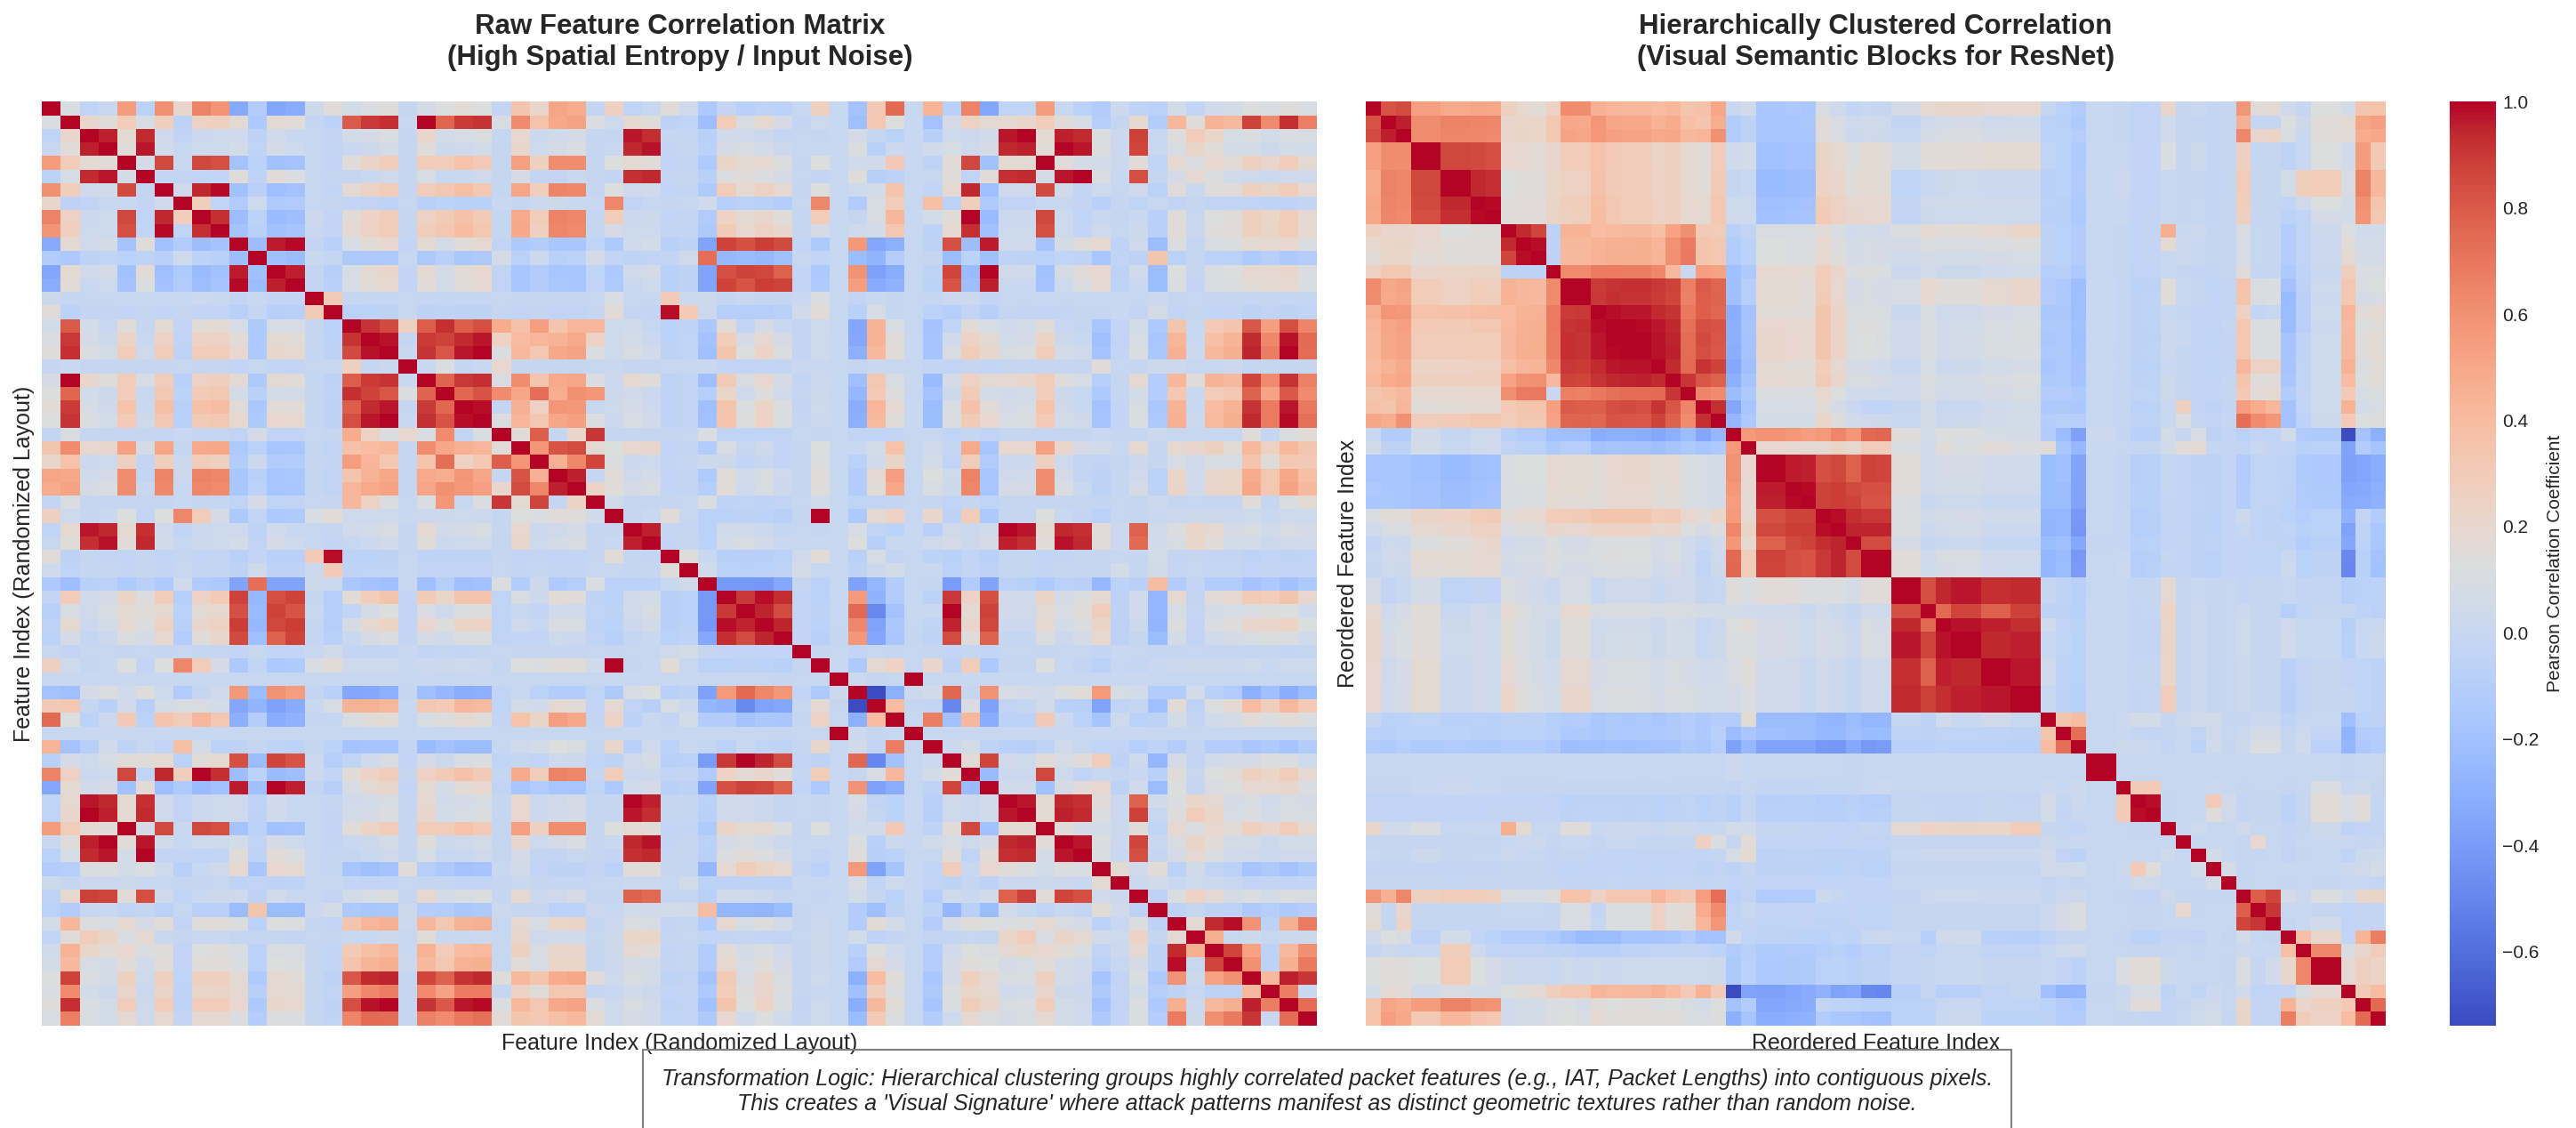

✅ Spatial verification complete. Structured groupings successfully established on the active data slice.


In [10]:
# --- 6. SPATIAL REORDERING VERIFICATION (DUAL-CORRELATION HEATMAPS) ---
print("Generating comparative visualization plots...")

# Extract correlation matrices directly from active data state dataframes
original_corr = X_filtered.corr().fillna(0)
reordered_corr = X_filtered[ordered_features].corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot A: Left Matrix (Raw Chaos)
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized Layout)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized Layout)", fontsize=12)

# Plot B: Right Matrix (Organized Visual Semantic Blocks)
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Structural Text Explanation Block Injection for Research Paper
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"Spatial verification complete. Structured groupings successfully established on the active data slice.")

----------2. Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [11]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Raw Flow Shape: 286,467 Rows | 79 Columns
Post-Sanitization Volume: 214,114 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'PortScan']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [12]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [13]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

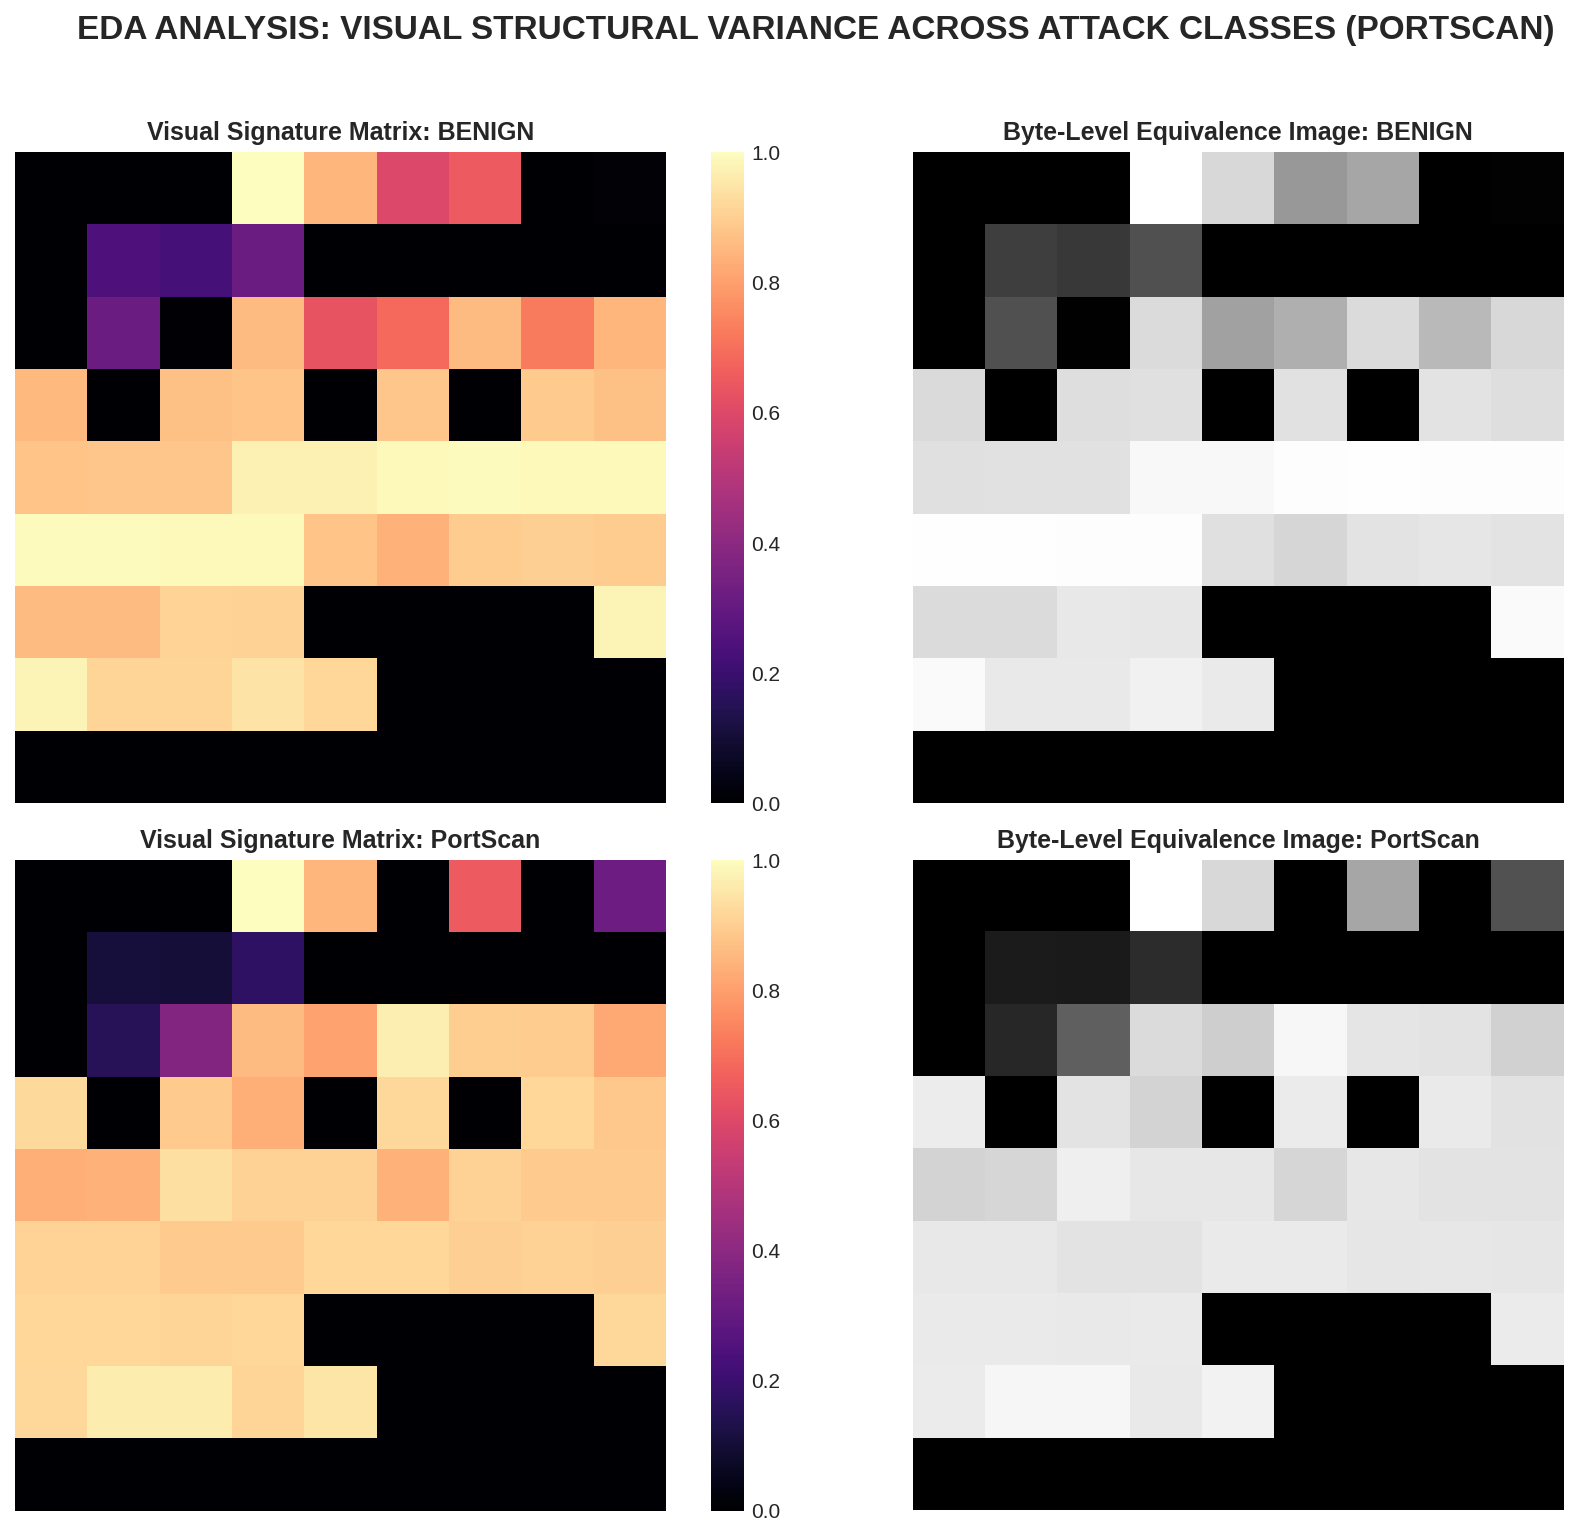

In [14]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (PORTSCAN)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


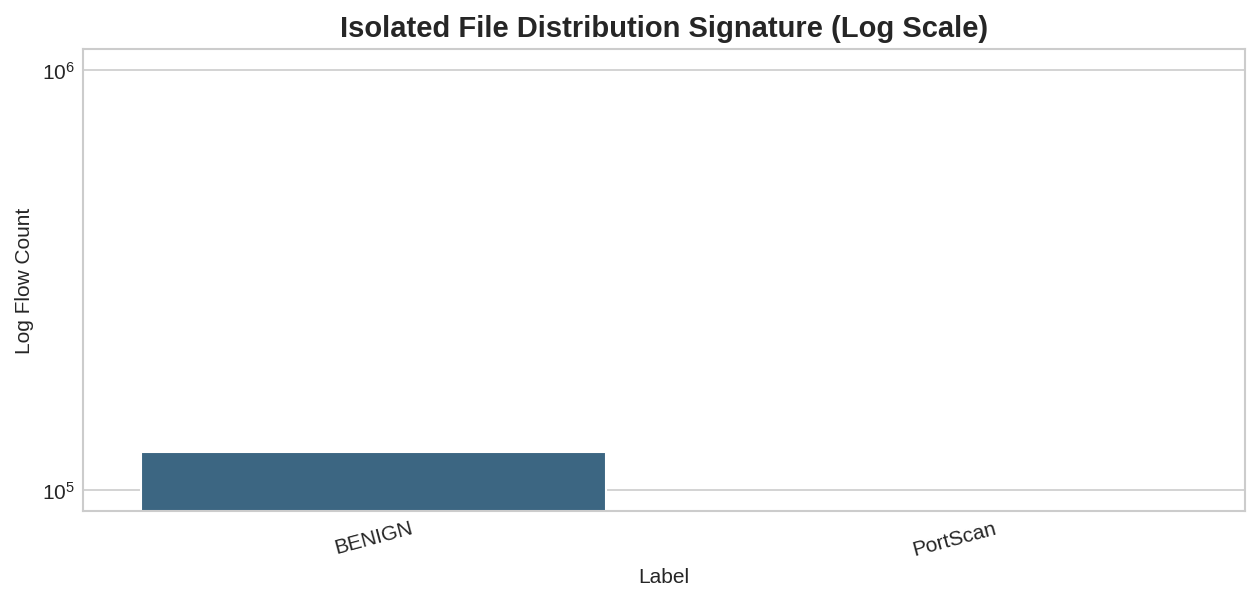

Current Sub-split Frequency Index:
 🔹 BENIGN          : 123,295 flows (57.58%)
 🔹 PortScan        : 90,819 flows (42.42%)


In [15]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

Generating PortScan file correlation matrix transformation graphics...


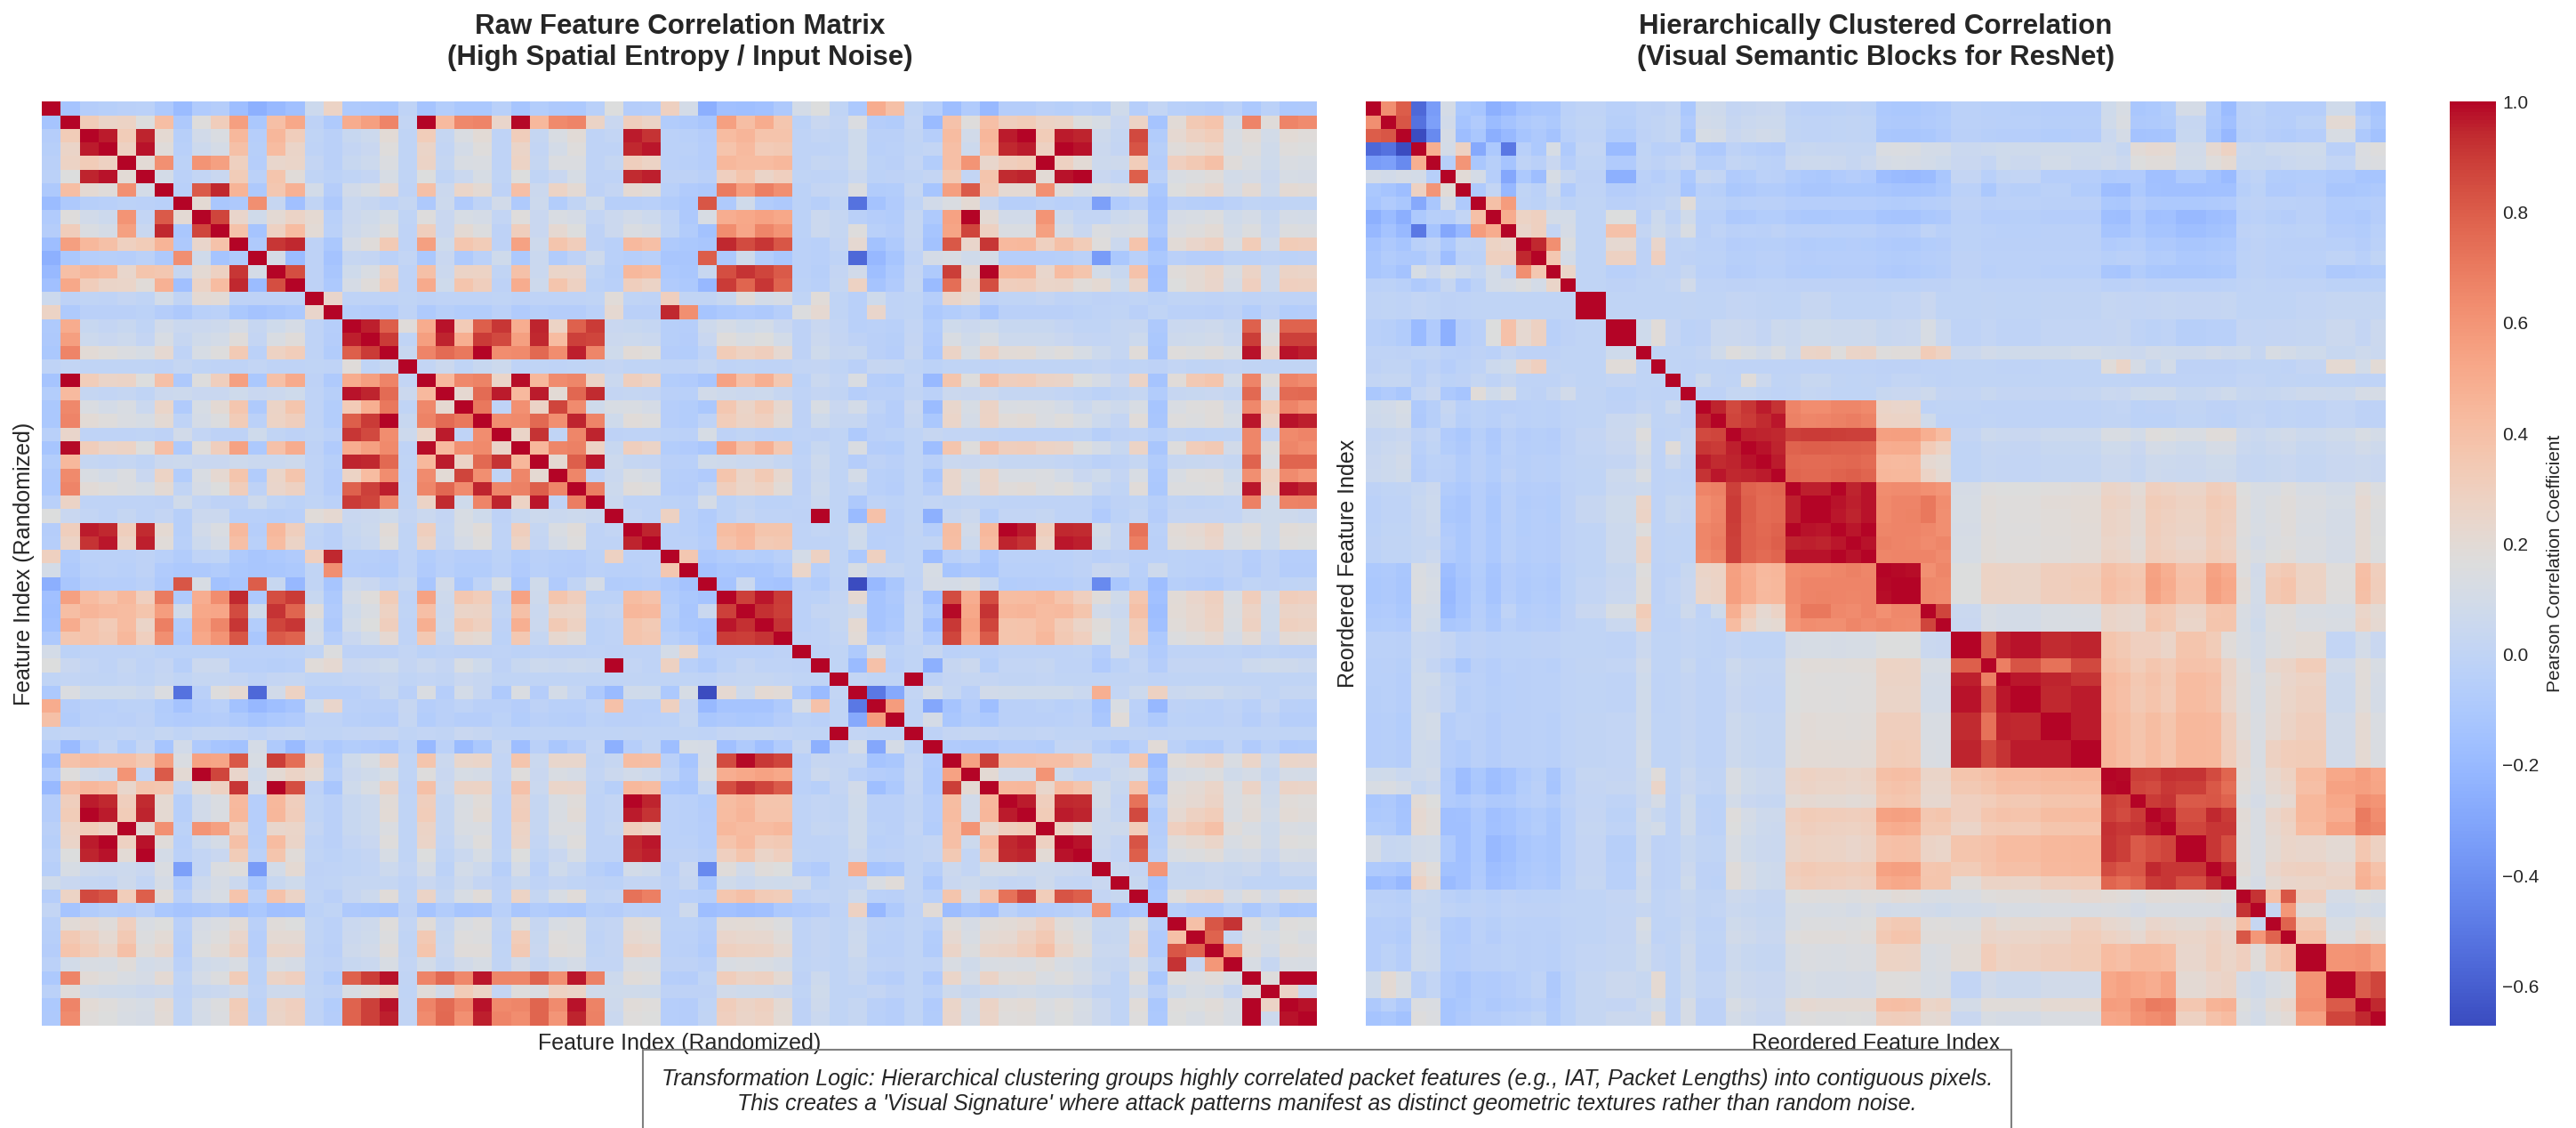

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


14530

In [16]:
print("Generating PortScan file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend metadata caption injection
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(features_to_map.columns) if 'features_to_map' in locals() else len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

 ----------3. Friday-WorkingHours-Morning.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [17]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Friday-WorkingHours-Morning.pcap_ISCX.csv
Raw Flow Shape: 191,033 Rows | 79 Columns
Post-Sanitization Volume: 184,145 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'Bot']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [18]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [19]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

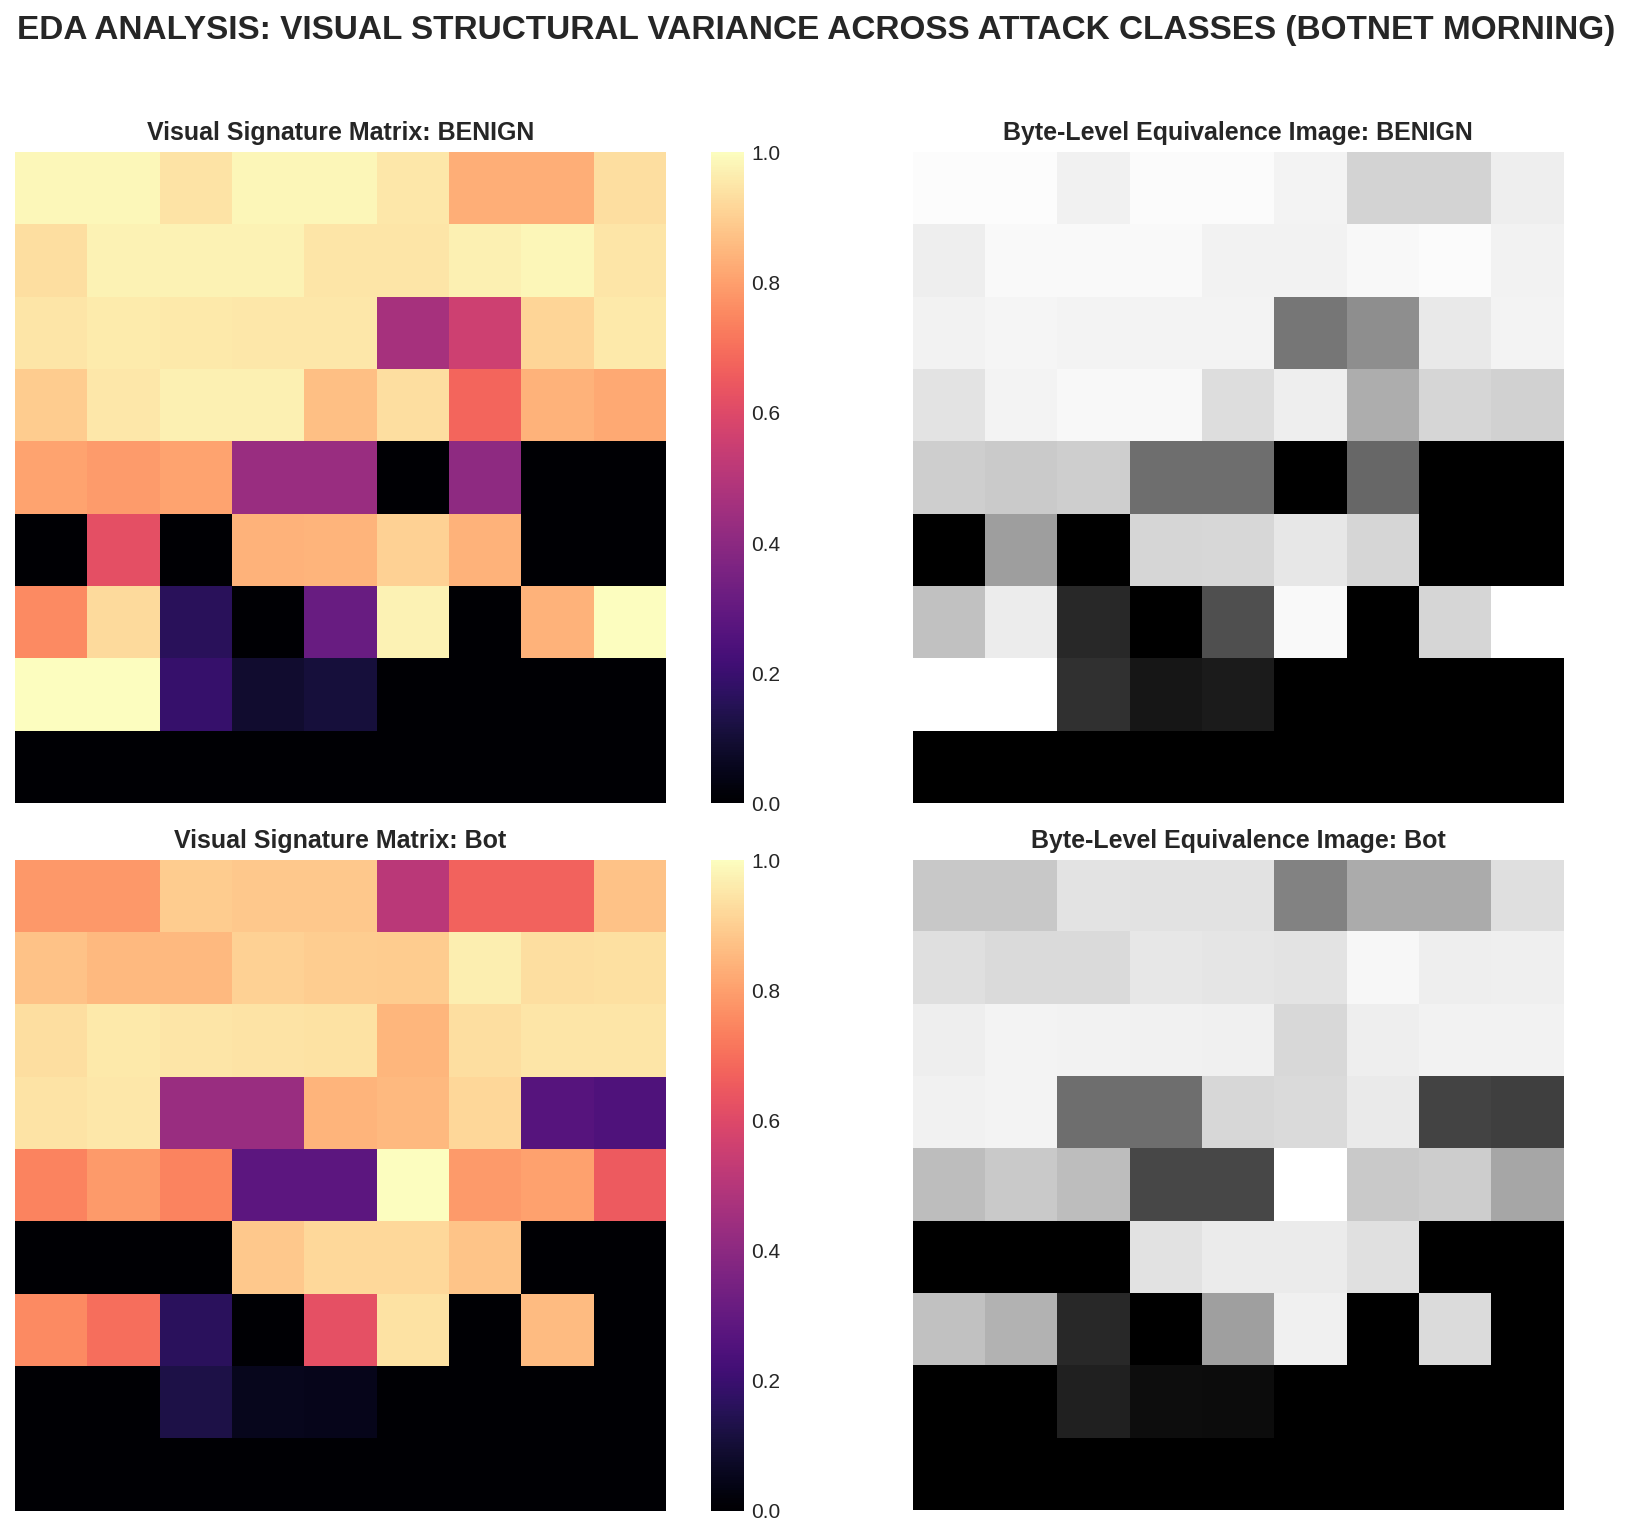

In [20]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (BOTNET MORNING)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


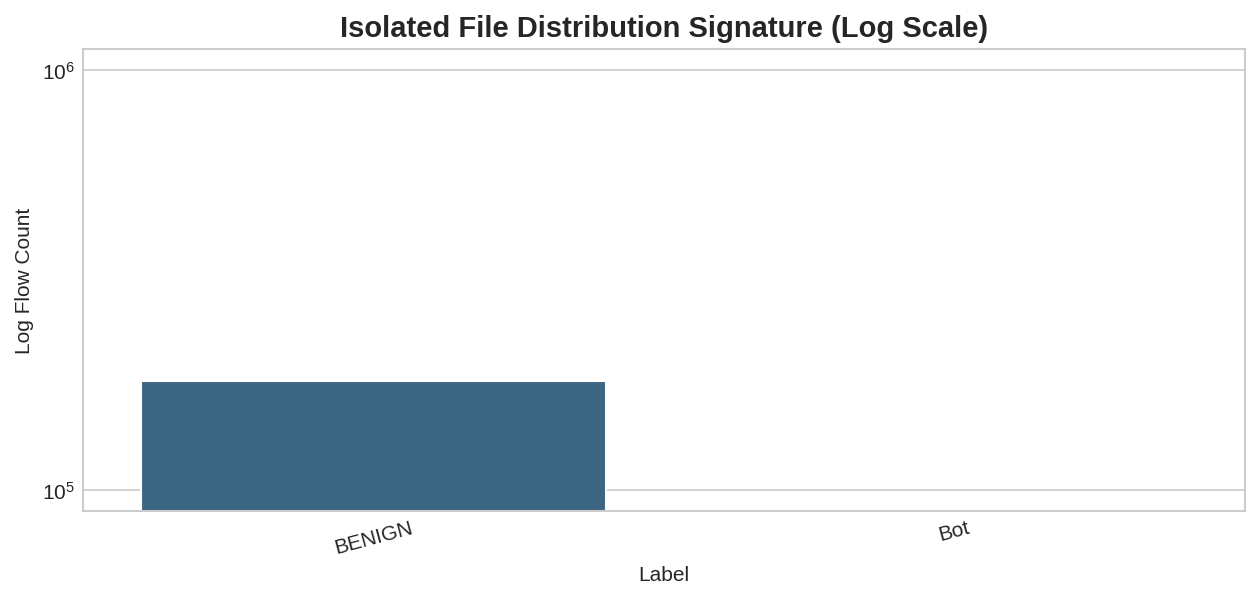

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 182,192 flows (98.94%)
 🔹 Bot             : 1,953 flows (1.06%)


In [21]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Morning file correlation matrix transformation graphics...


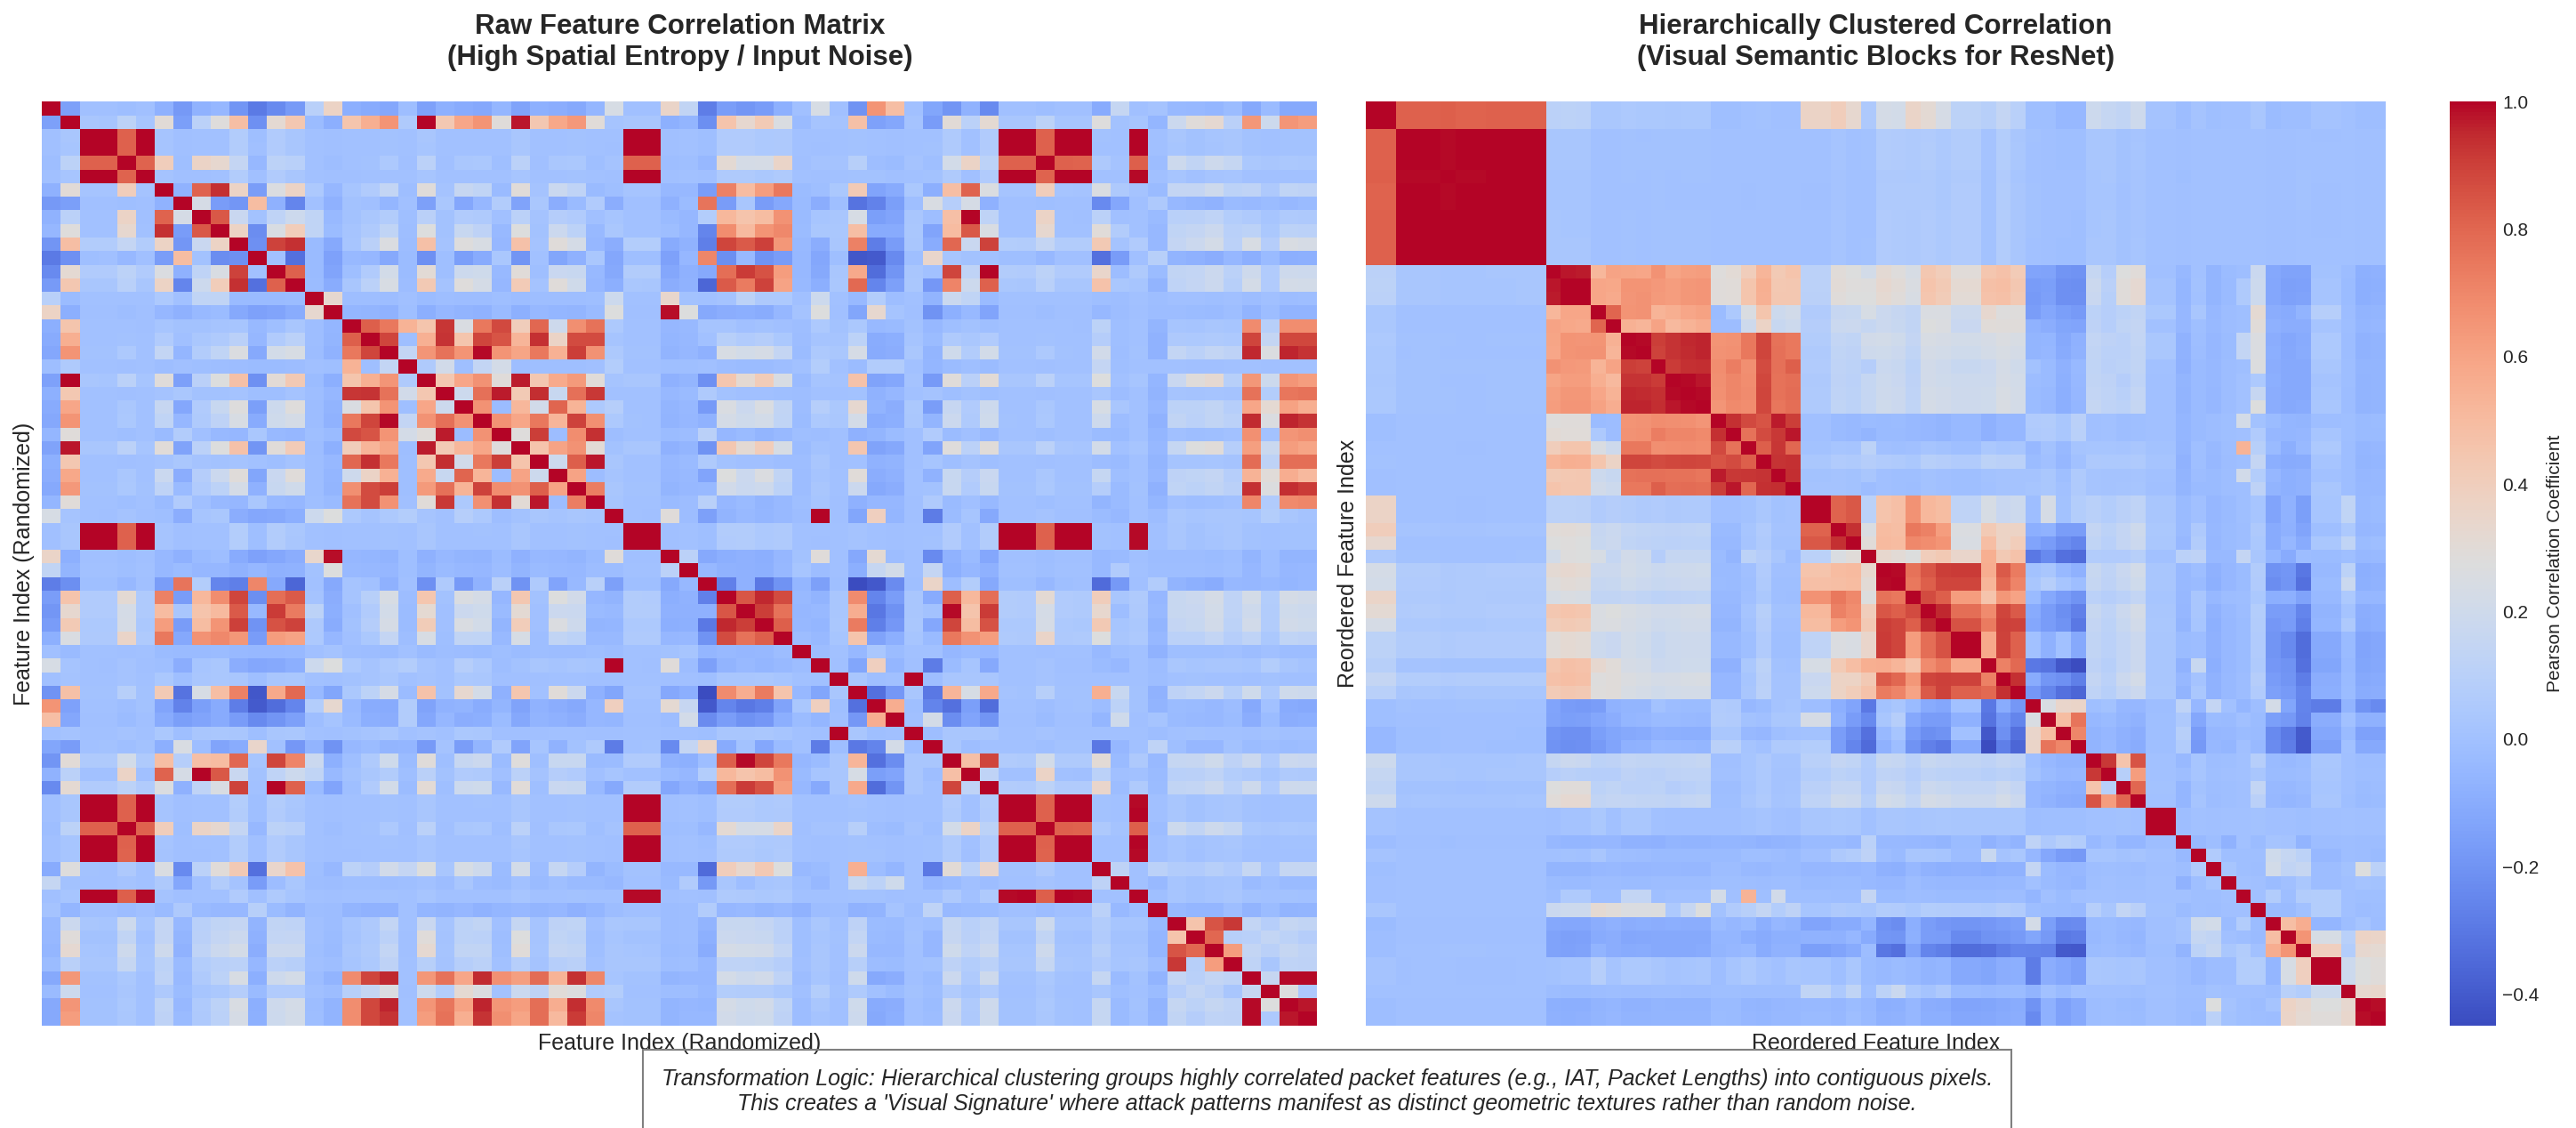

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


28258

In [22]:
print(" Generating Morning file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

----------4. Monday-WorkingHours.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [23]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Monday-WorkingHours.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Monday-WorkingHours.pcap_ISCX.csv
Raw Flow Shape: 529,918 Rows | 79 Columns
Post-Sanitization Volume: 502,983 Unique Network Flows
Target Ground Truths Available: ['BENIGN']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [24]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [25]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

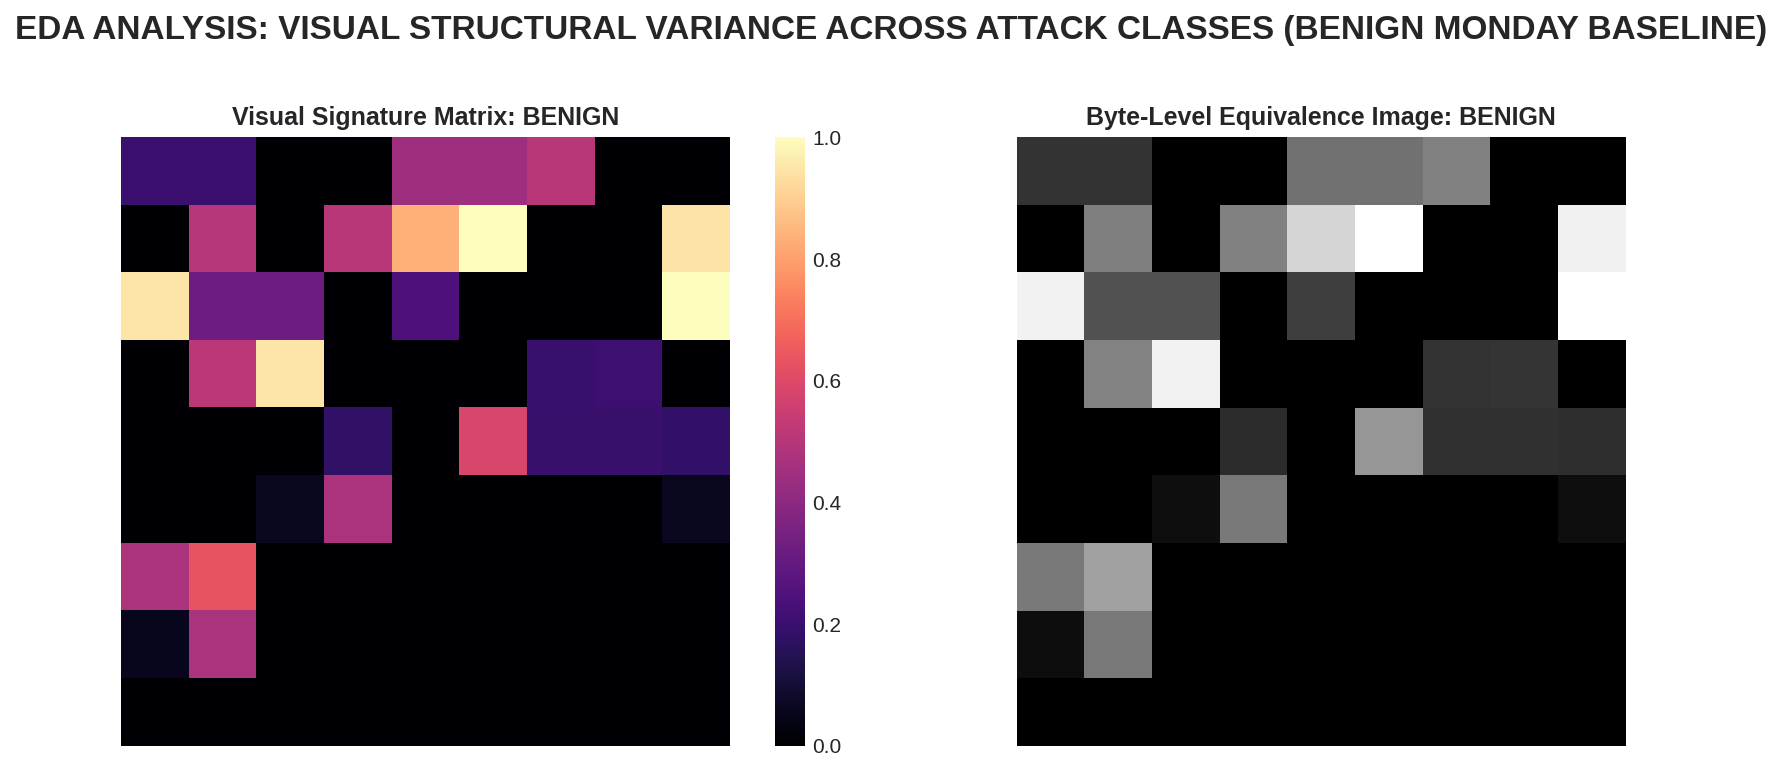

In [26]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (BENIGN MONDAY BASELINE)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

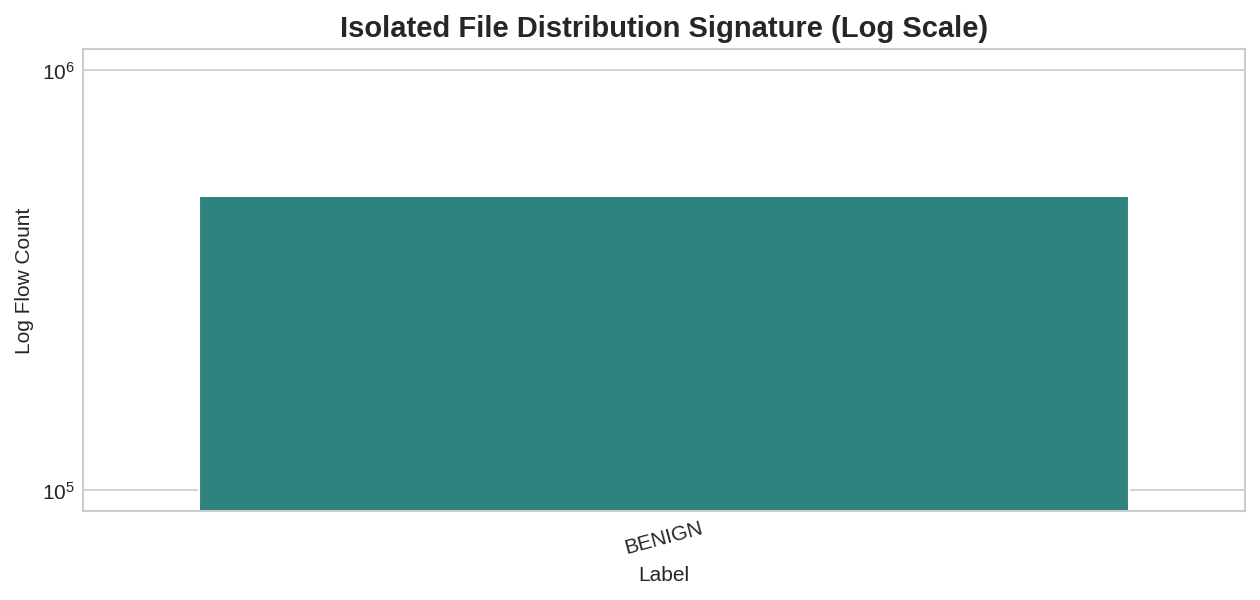

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 502,983 flows (100.00%)


In [27]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Monday Baseline file correlation matrix transformation graphics...


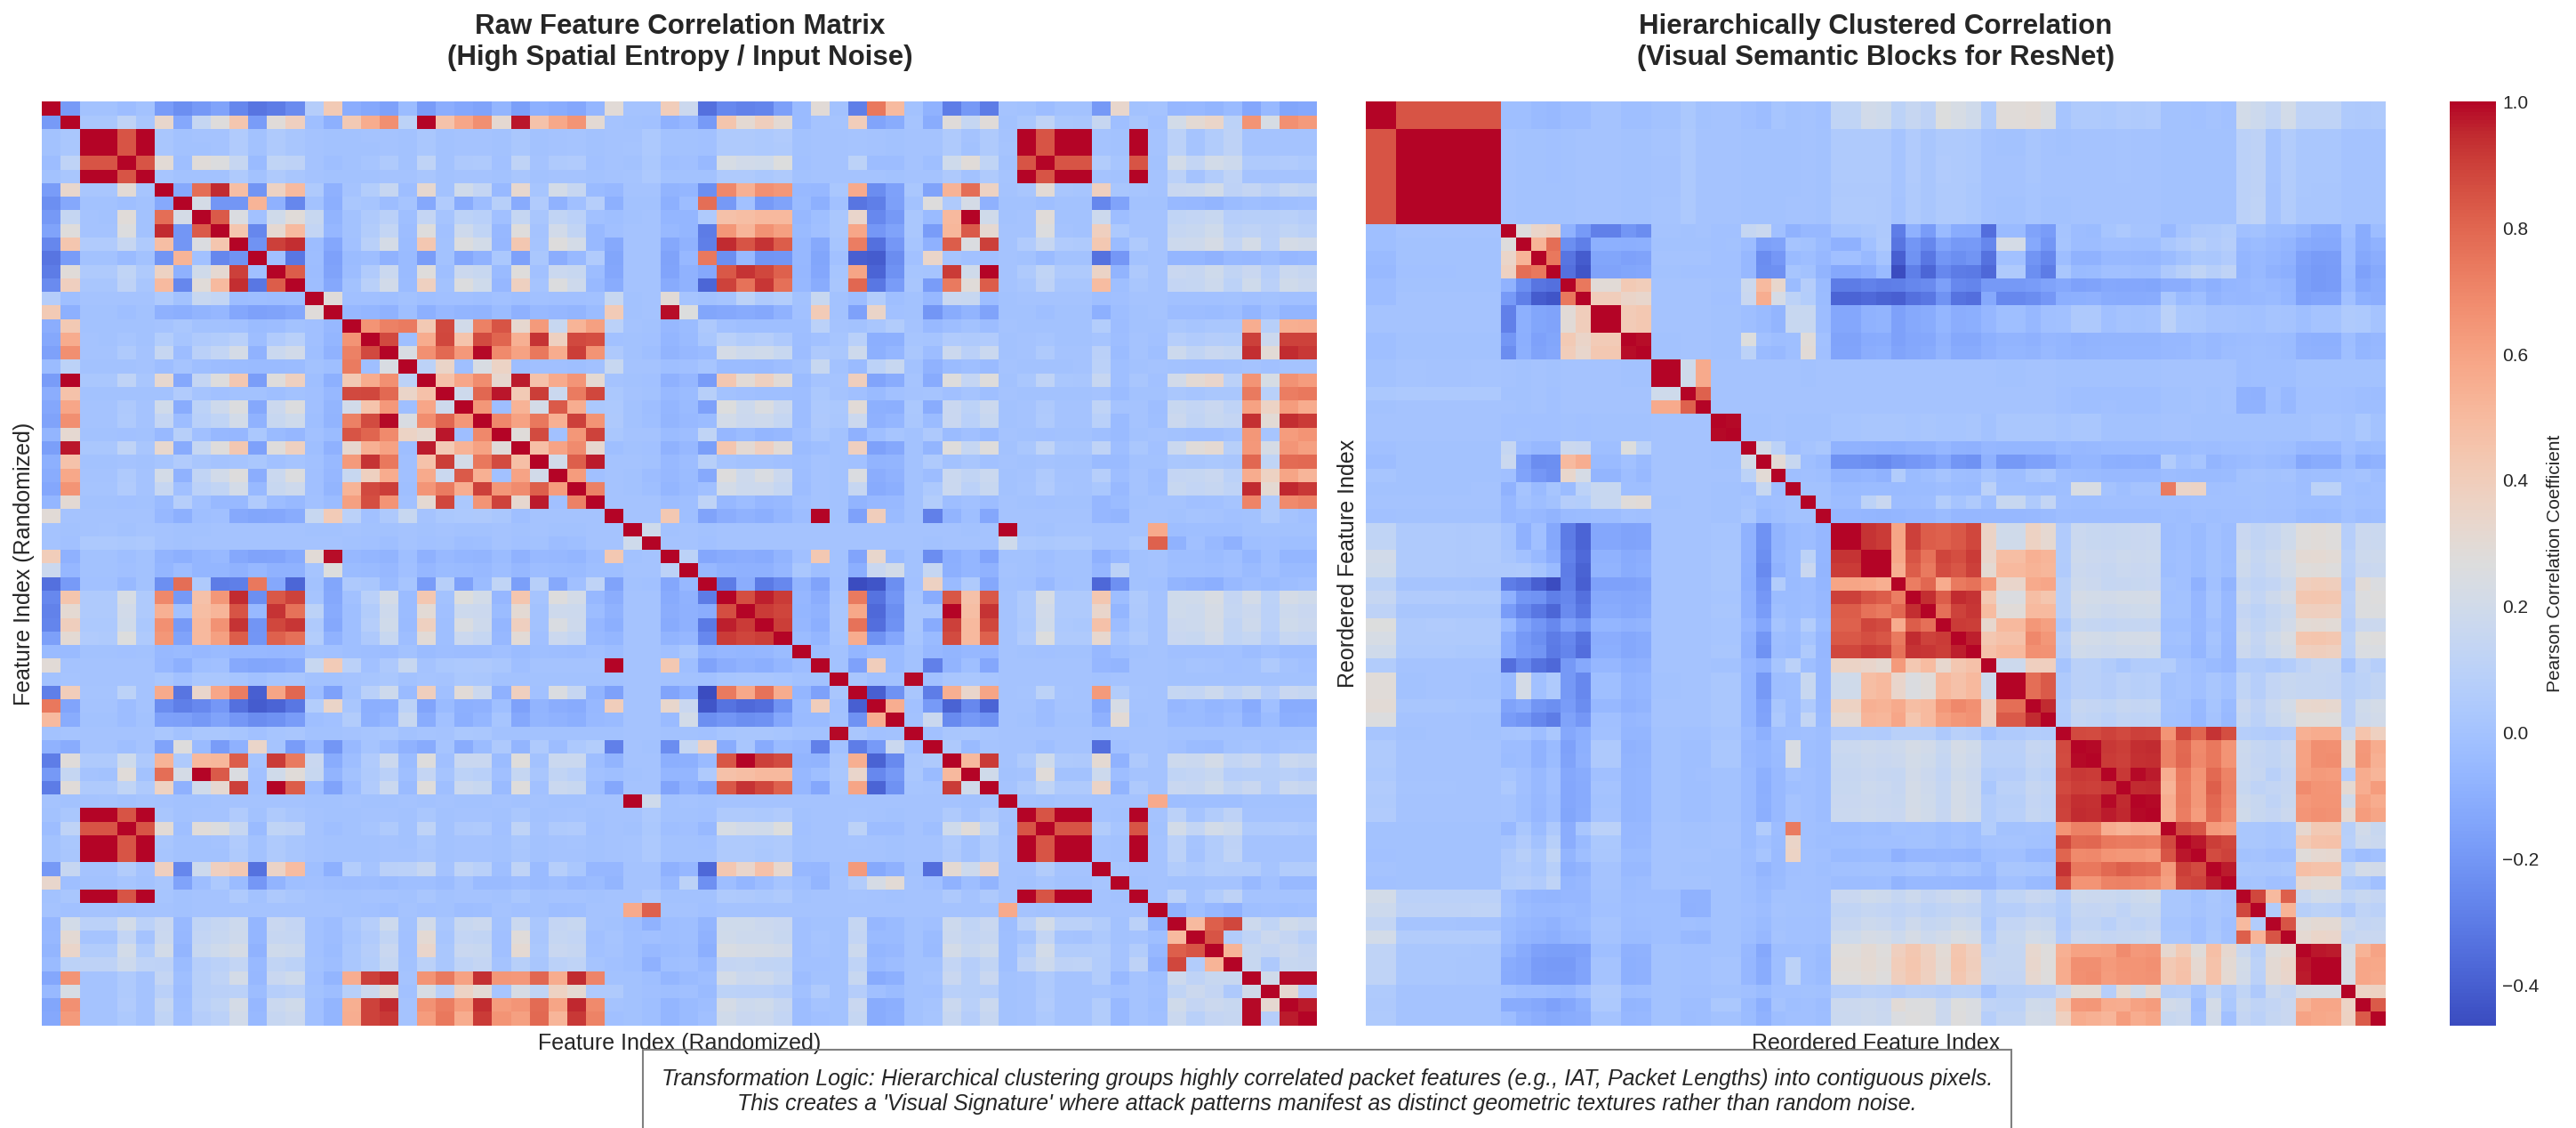

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


27538

In [28]:
print(" Generating Monday Baseline file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

 ----------5. Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [29]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Raw Flow Shape: 288,602 Rows | 79 Columns
Post-Sanitization Volume: 252,972 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'Infiltration']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [30]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 8 zero-variance columns.
Modeling 70 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [31]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

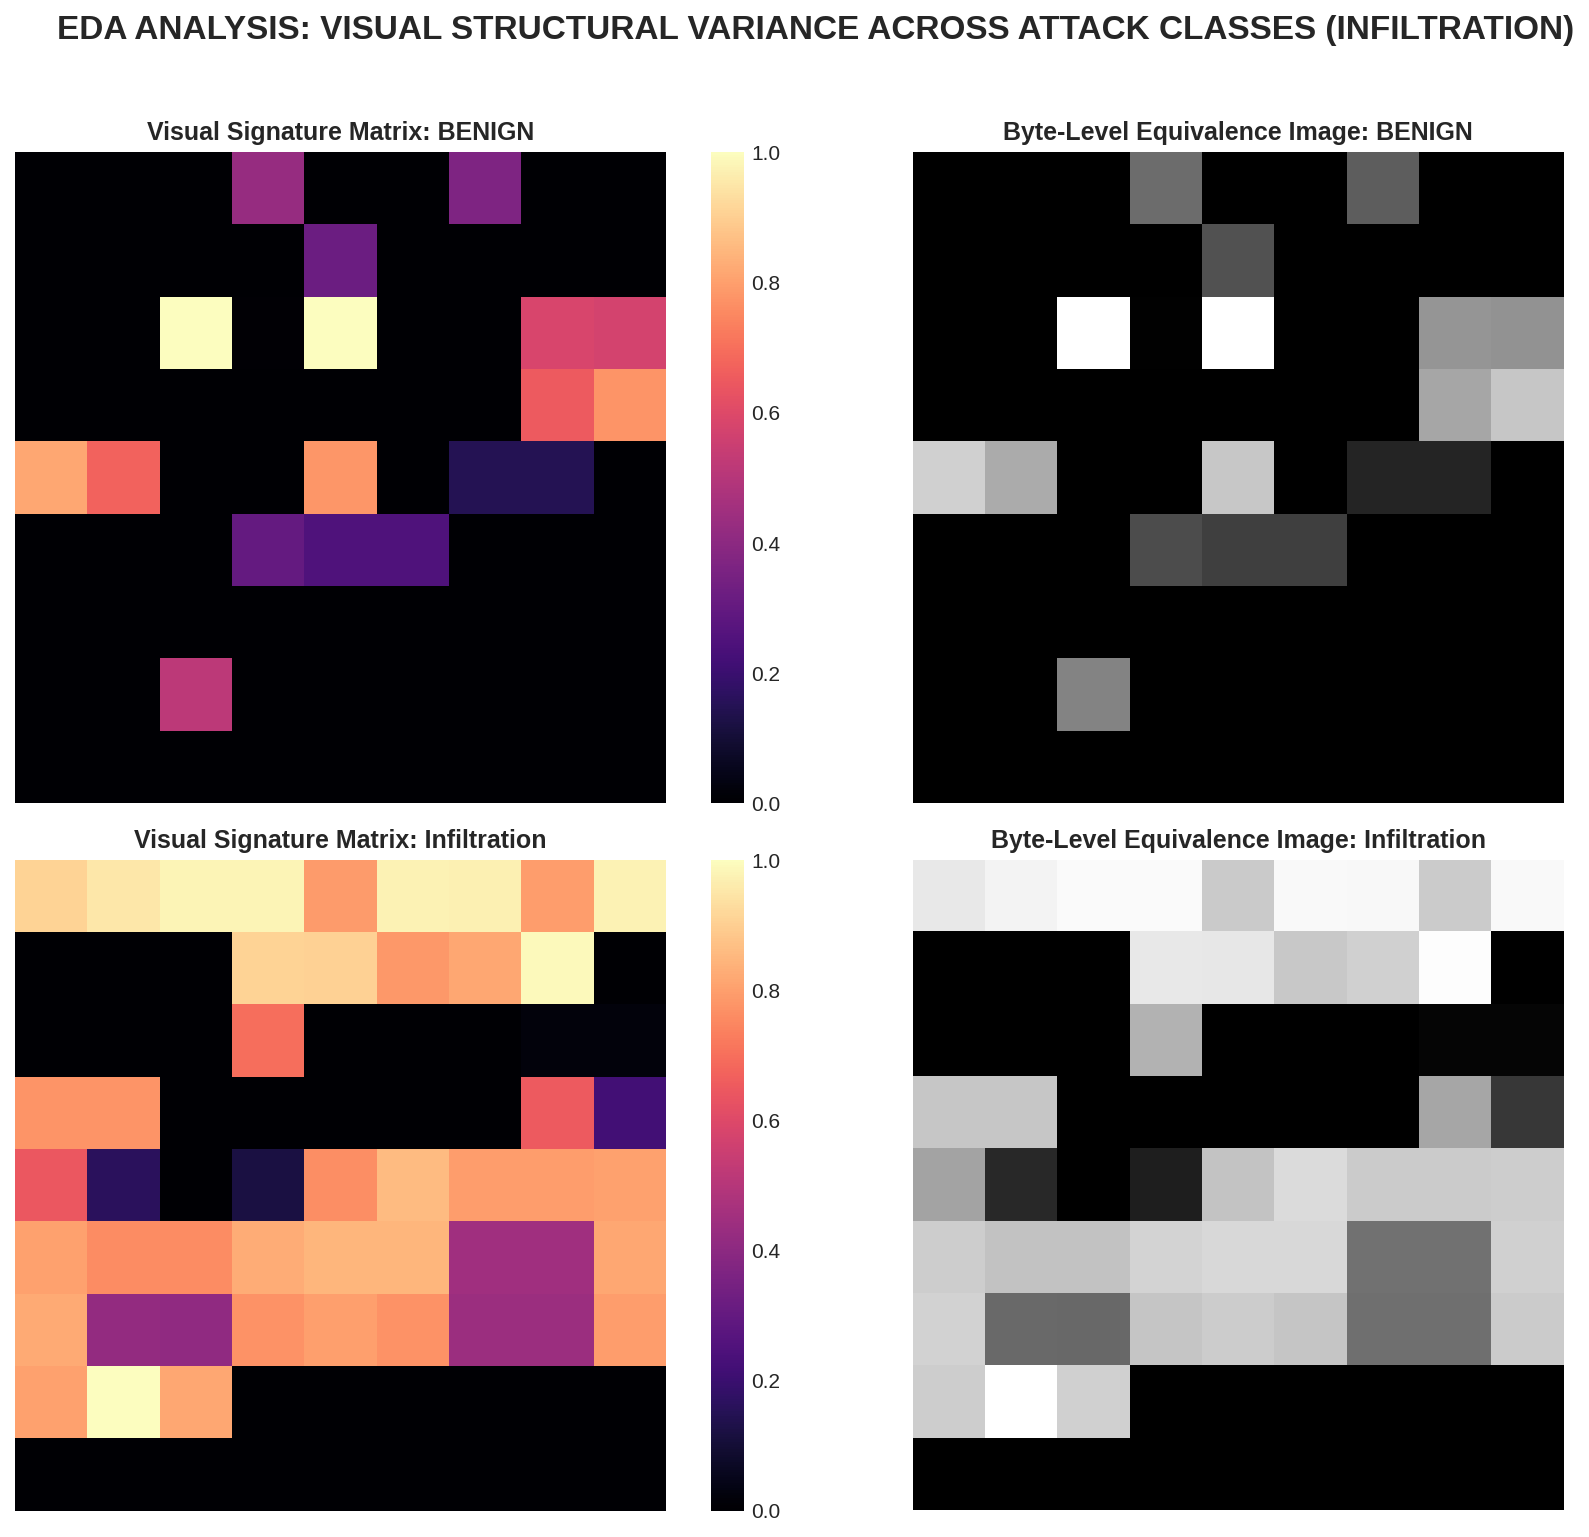

In [32]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (INFILTRATION)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

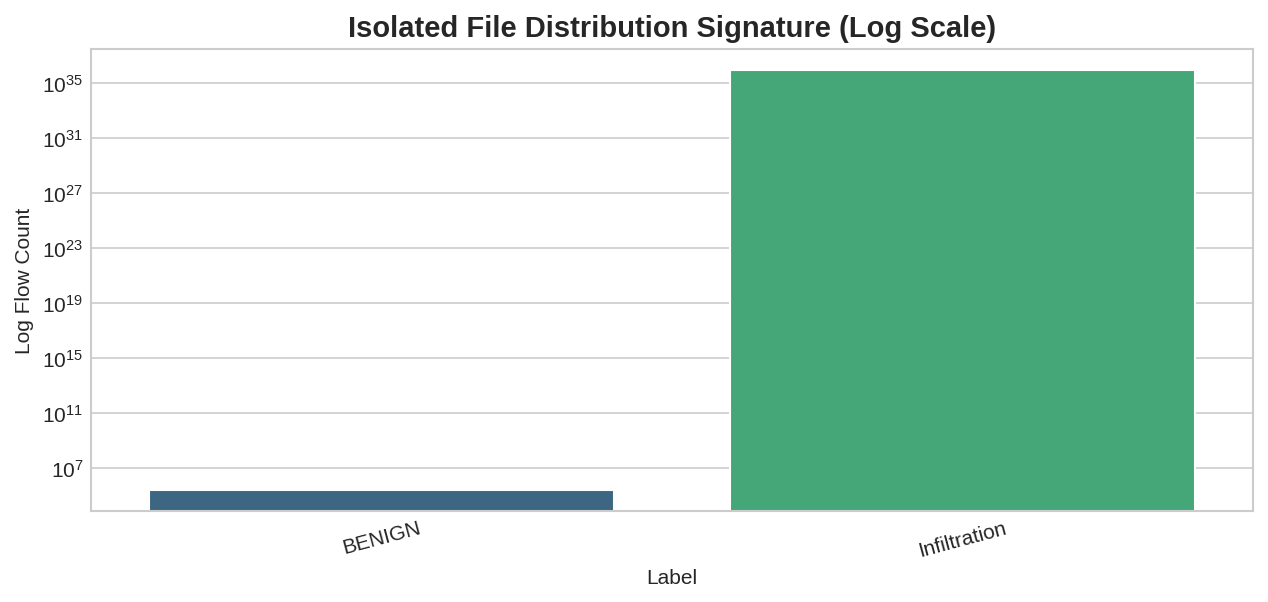

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 252,936 flows (99.99%)
 🔹 Infiltration    : 36 flows (0.01%)


In [33]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Infiltration file correlation matrix transformation graphics...


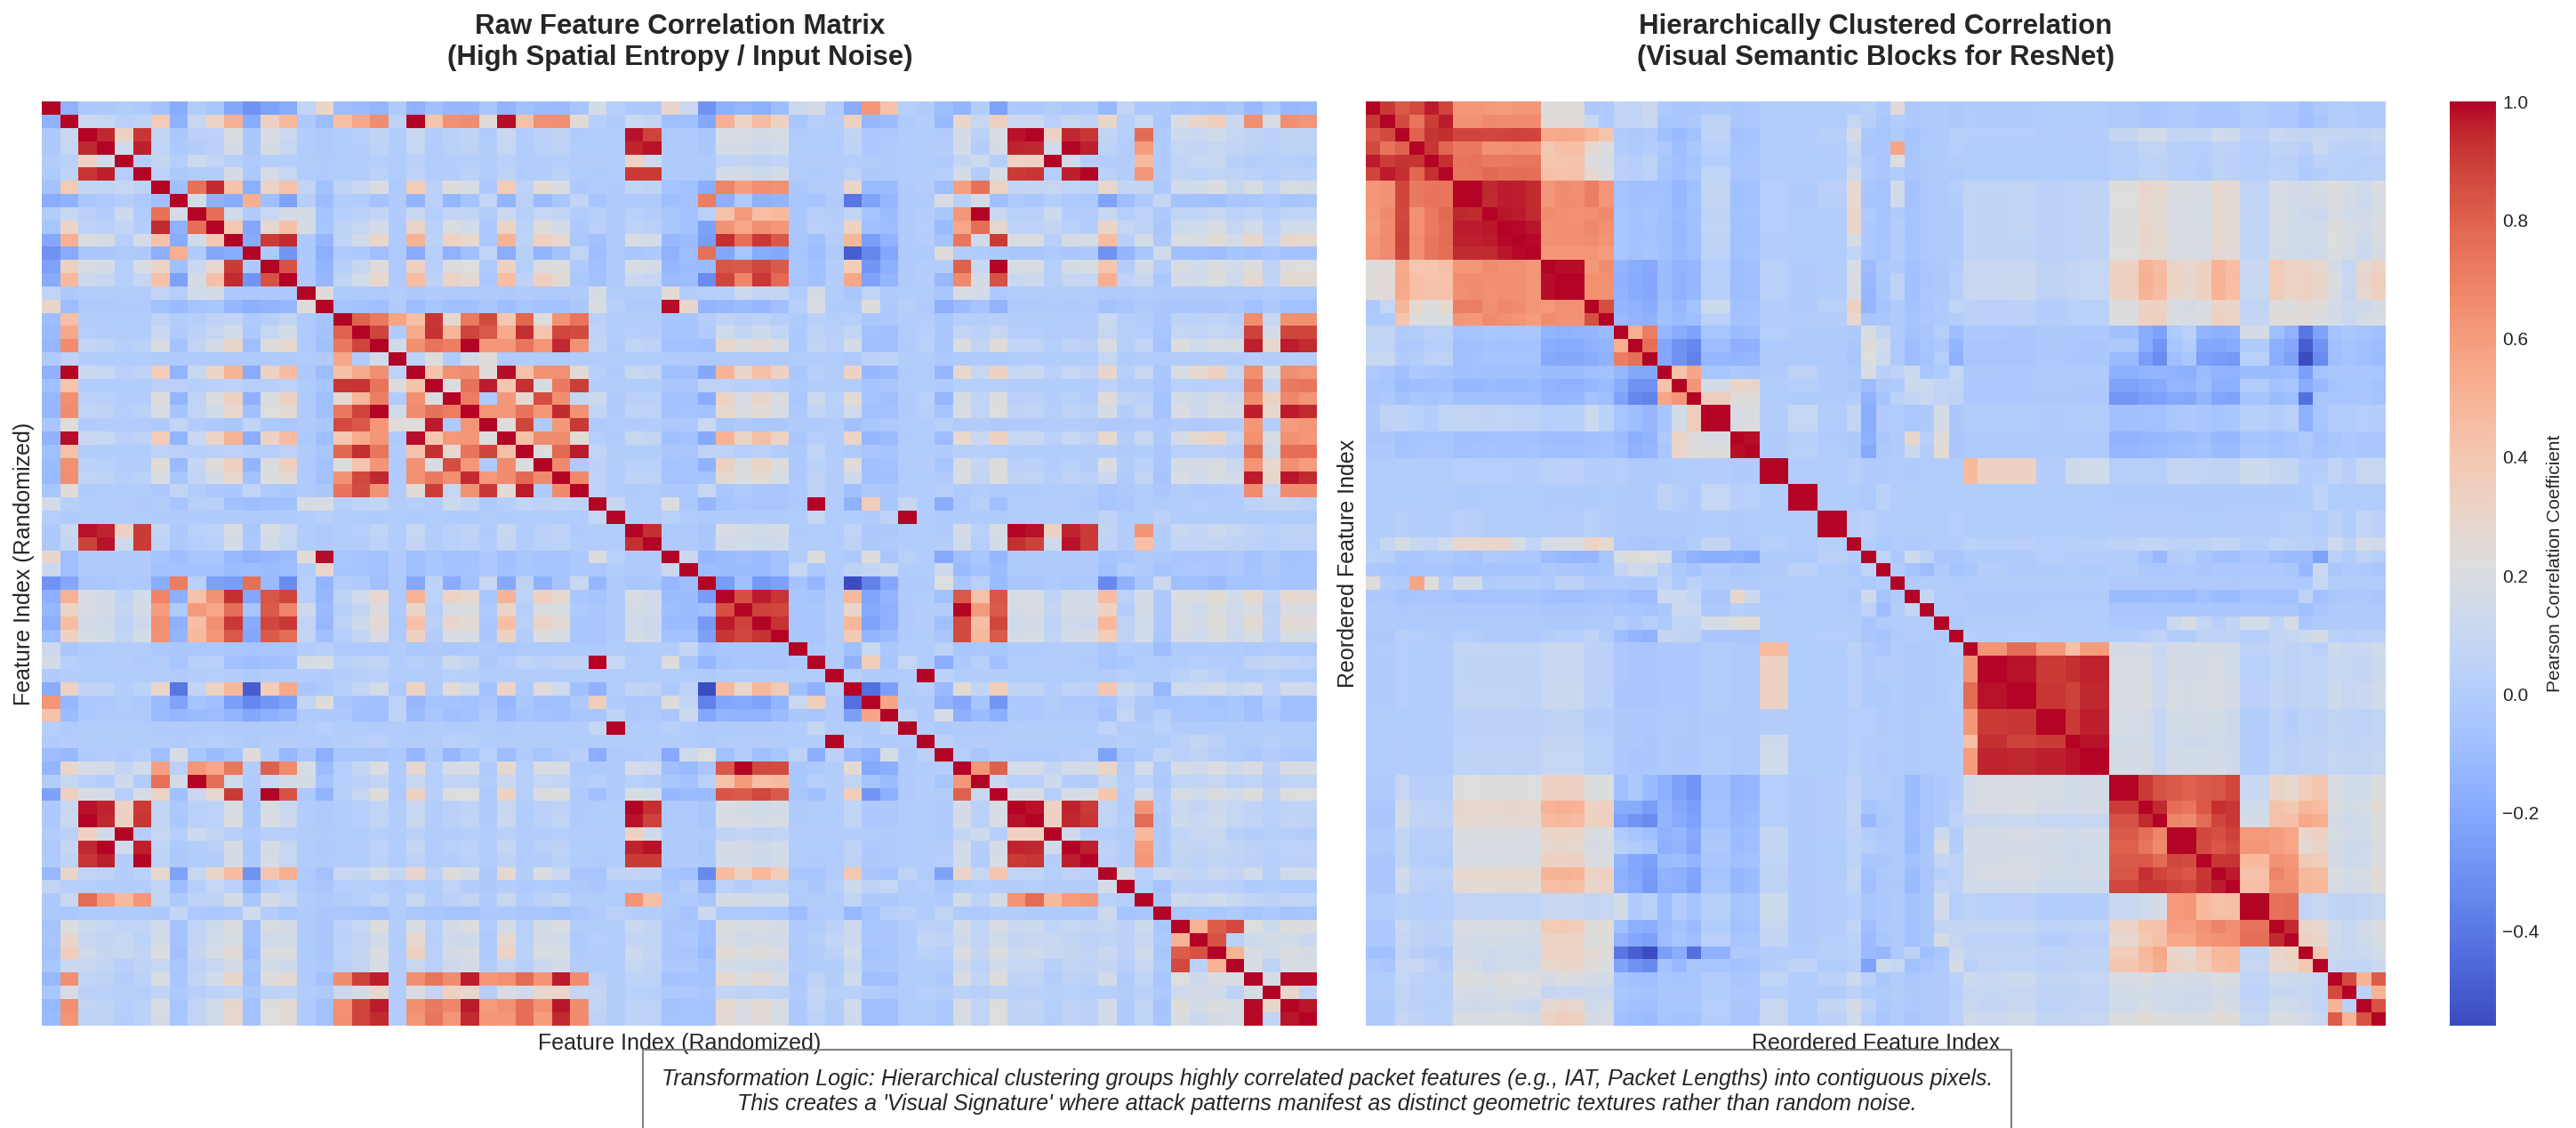

✅ Visualization complete. Reordering has successfully concentrated 70 features into dense visual structures.


24883

In [34]:
print(" Generating Infiltration file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

----------6. Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [35]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization & Whitespace Sanitization
df['Label'] = df['Label'].str.strip()
# Resolve raw dataset naming typos structurally
df['Label'] = df['Label'].replace({
    'Web Attack  Brute Force': 'Web Attack - Brute Force',
    'Web Attack  XSS': 'Web Attack - XSS',
    'Web Attack  Sql Injection': 'Web Attack - Sql Injection'
})

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Raw Flow Shape: 170,366 Rows | 79 Columns
Post-Sanitization Volume: 164,300 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [36]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [38]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/tmp/ipykernel_752/3826502724.py:26: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


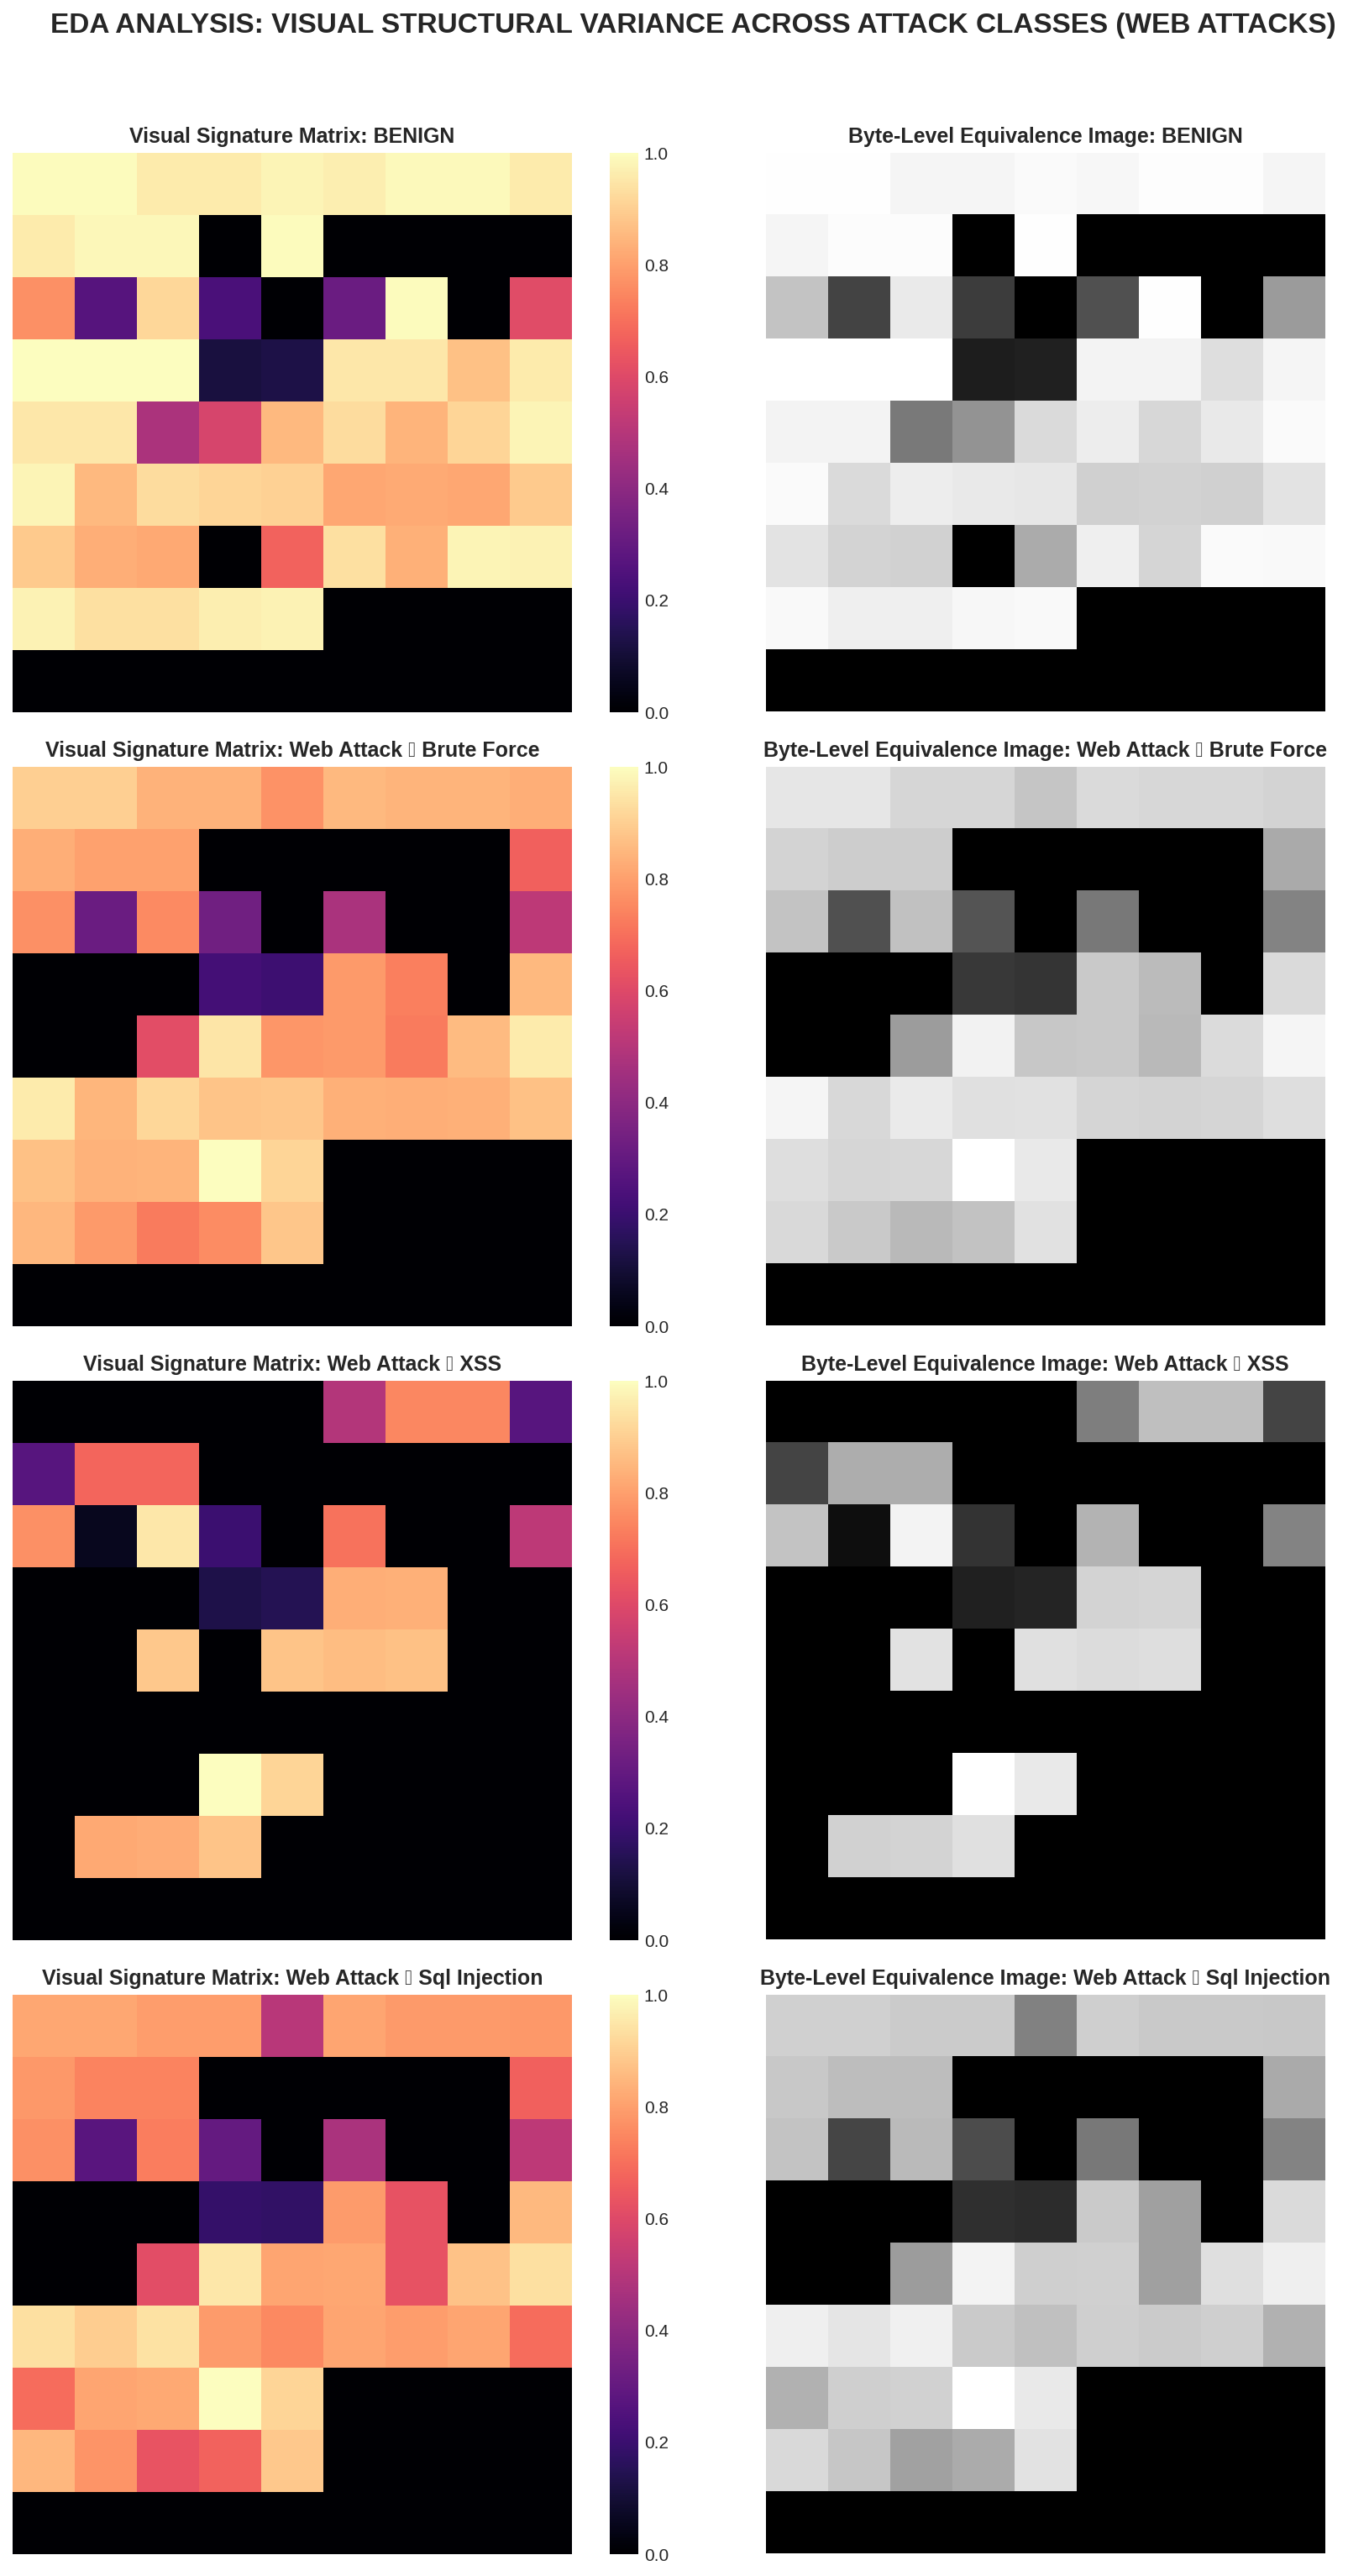

In [39]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (WEB ATTACKS)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


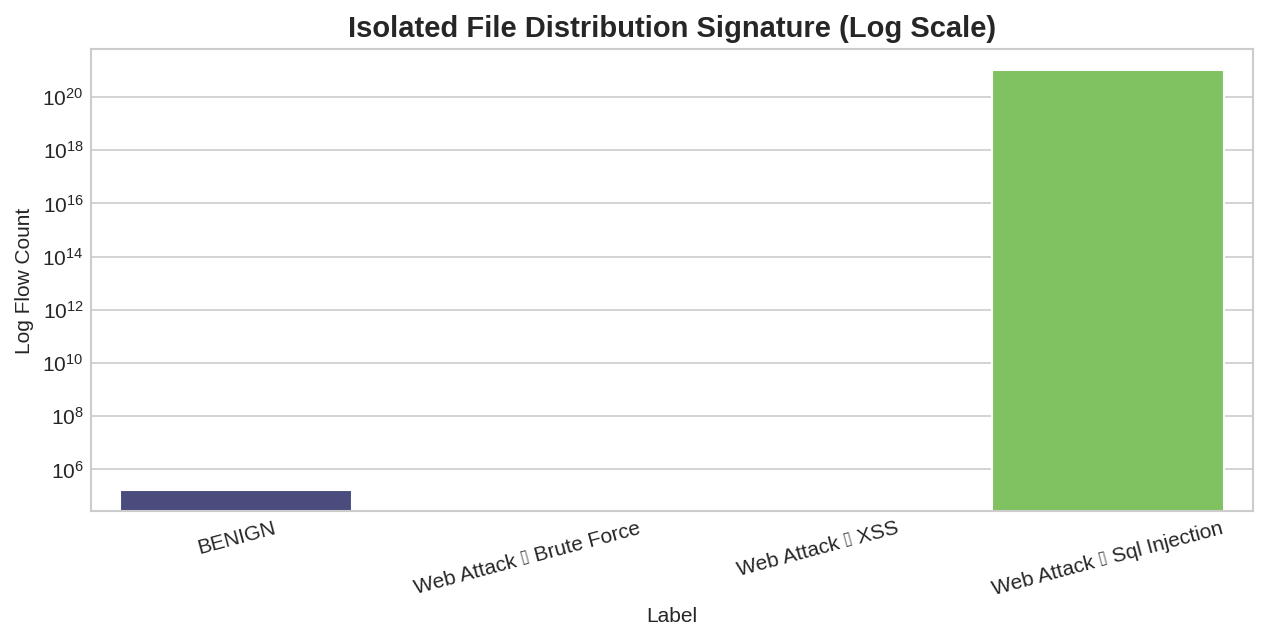

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 162,157 flows (98.70%)
 🔹 Web Attack � Brute Force : 1,470 flows (0.89%)
 🔹 Web Attack � XSS : 652 flows (0.40%)
 🔹 Web Attack � Sql Injection : 21 flows (0.01%)


In [40]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("📝 Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

📊 Generating Web Attacks file correlation matrix transformation graphics...


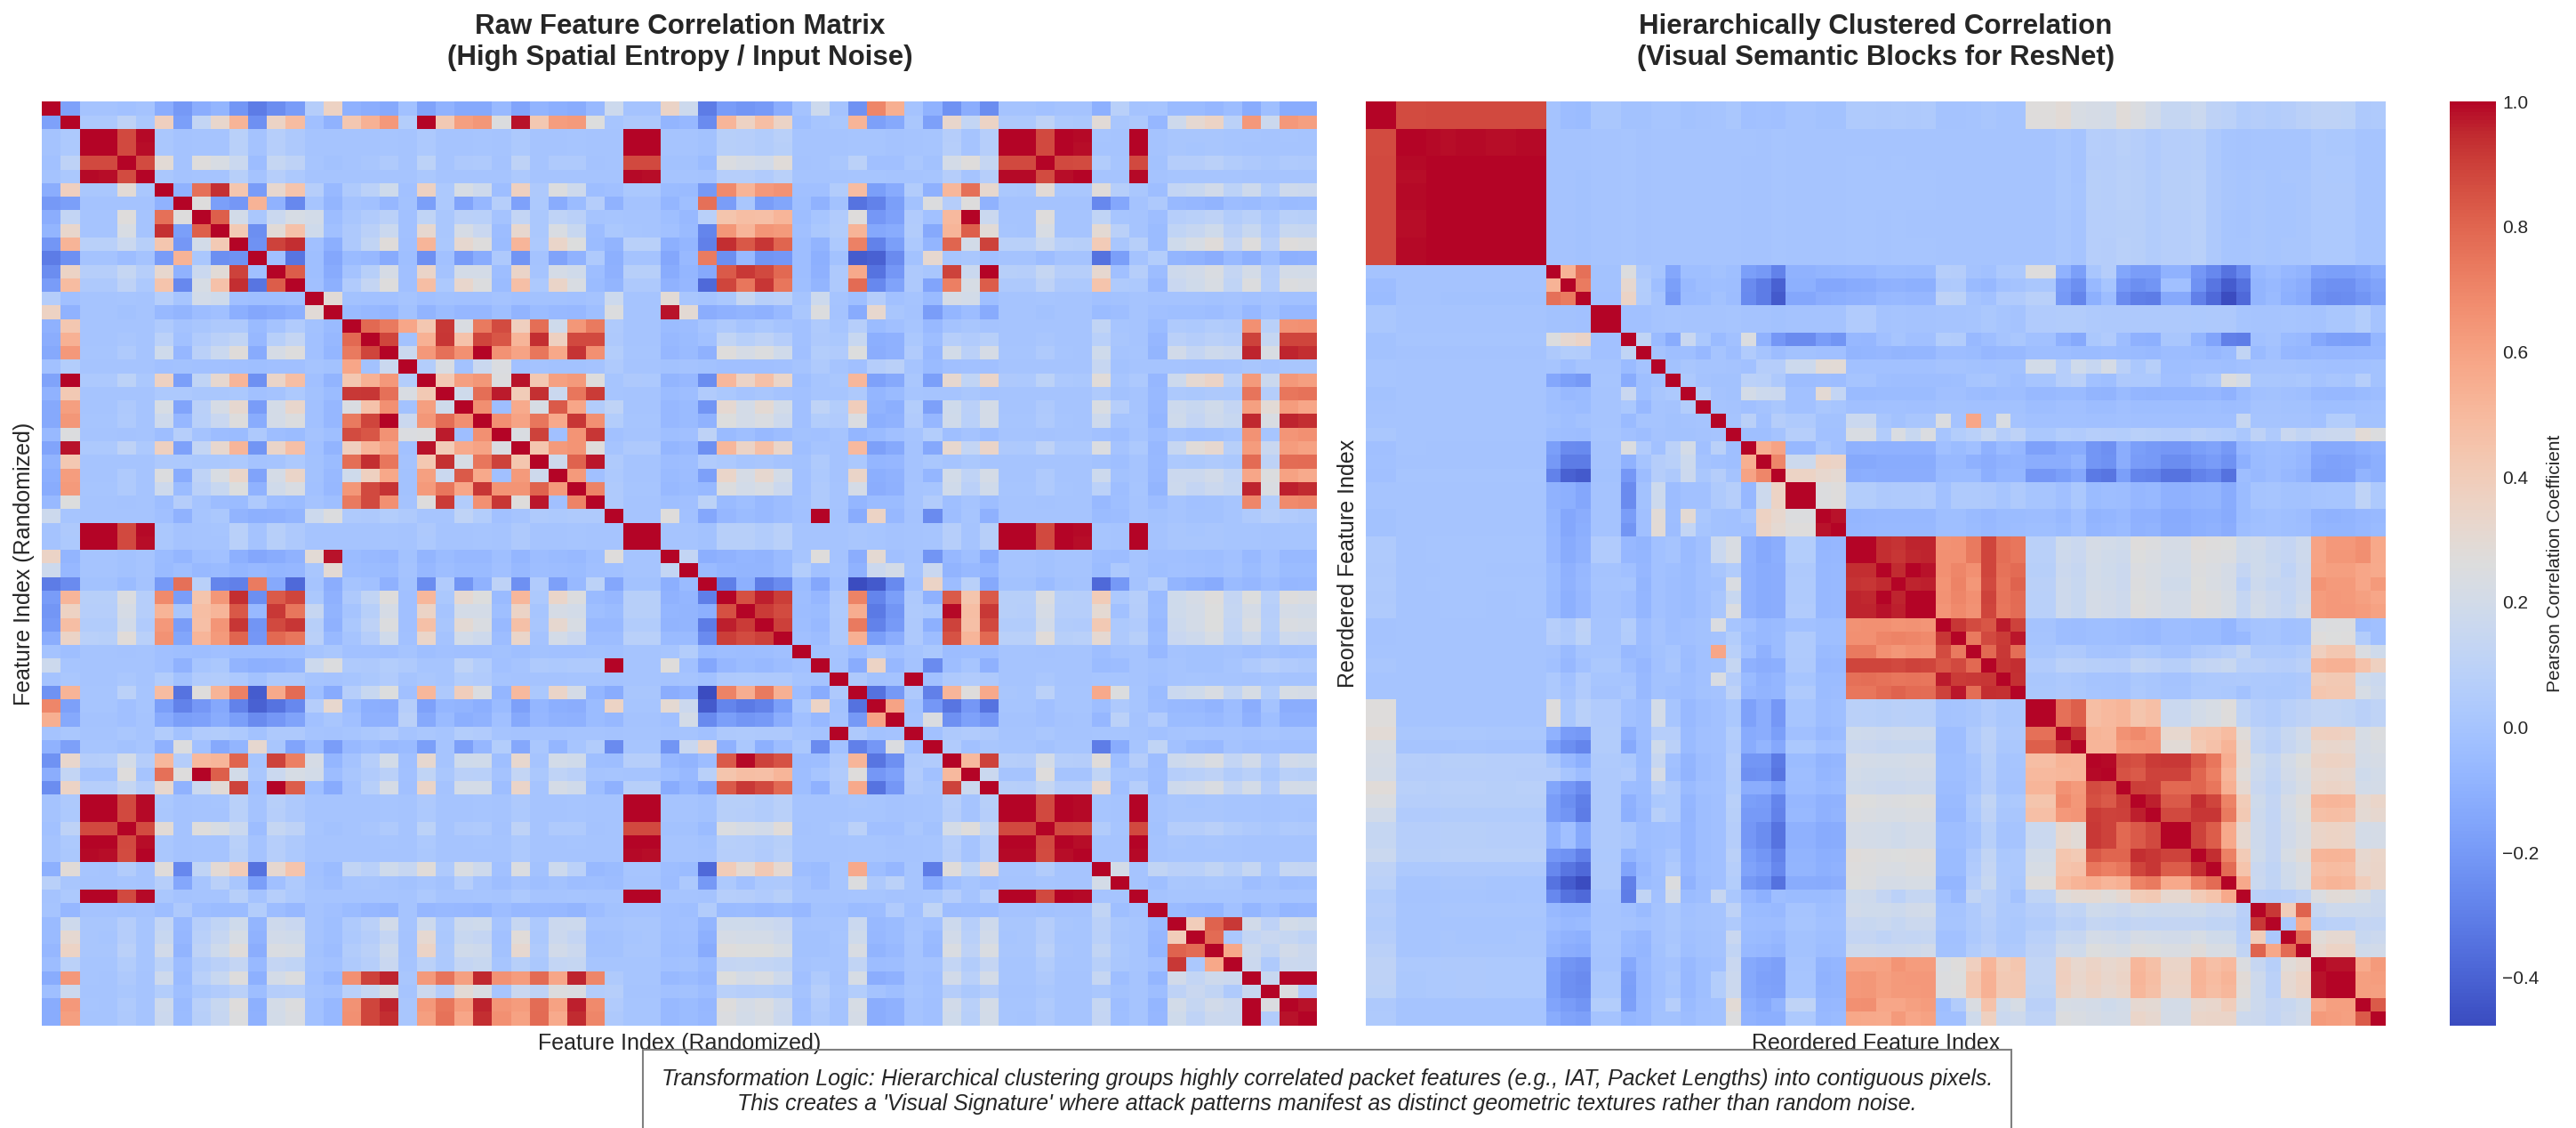

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


13490

In [41]:
print("📊 Generating Web Attacks file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"✅ Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

----------7. Tuesday-WorkingHours.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [42]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Tuesday-WorkingHours.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip malicious leading/trailing spaces

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization
df['Label'] = df['Label'].str.strip()

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Tuesday-WorkingHours.pcap_ISCX.csv
Raw Flow Shape: 445,909 Rows | 79 Columns
Post-Sanitization Volume: 421,844 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'FTP-Patator' 'SSH-Patator']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [43]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [44]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

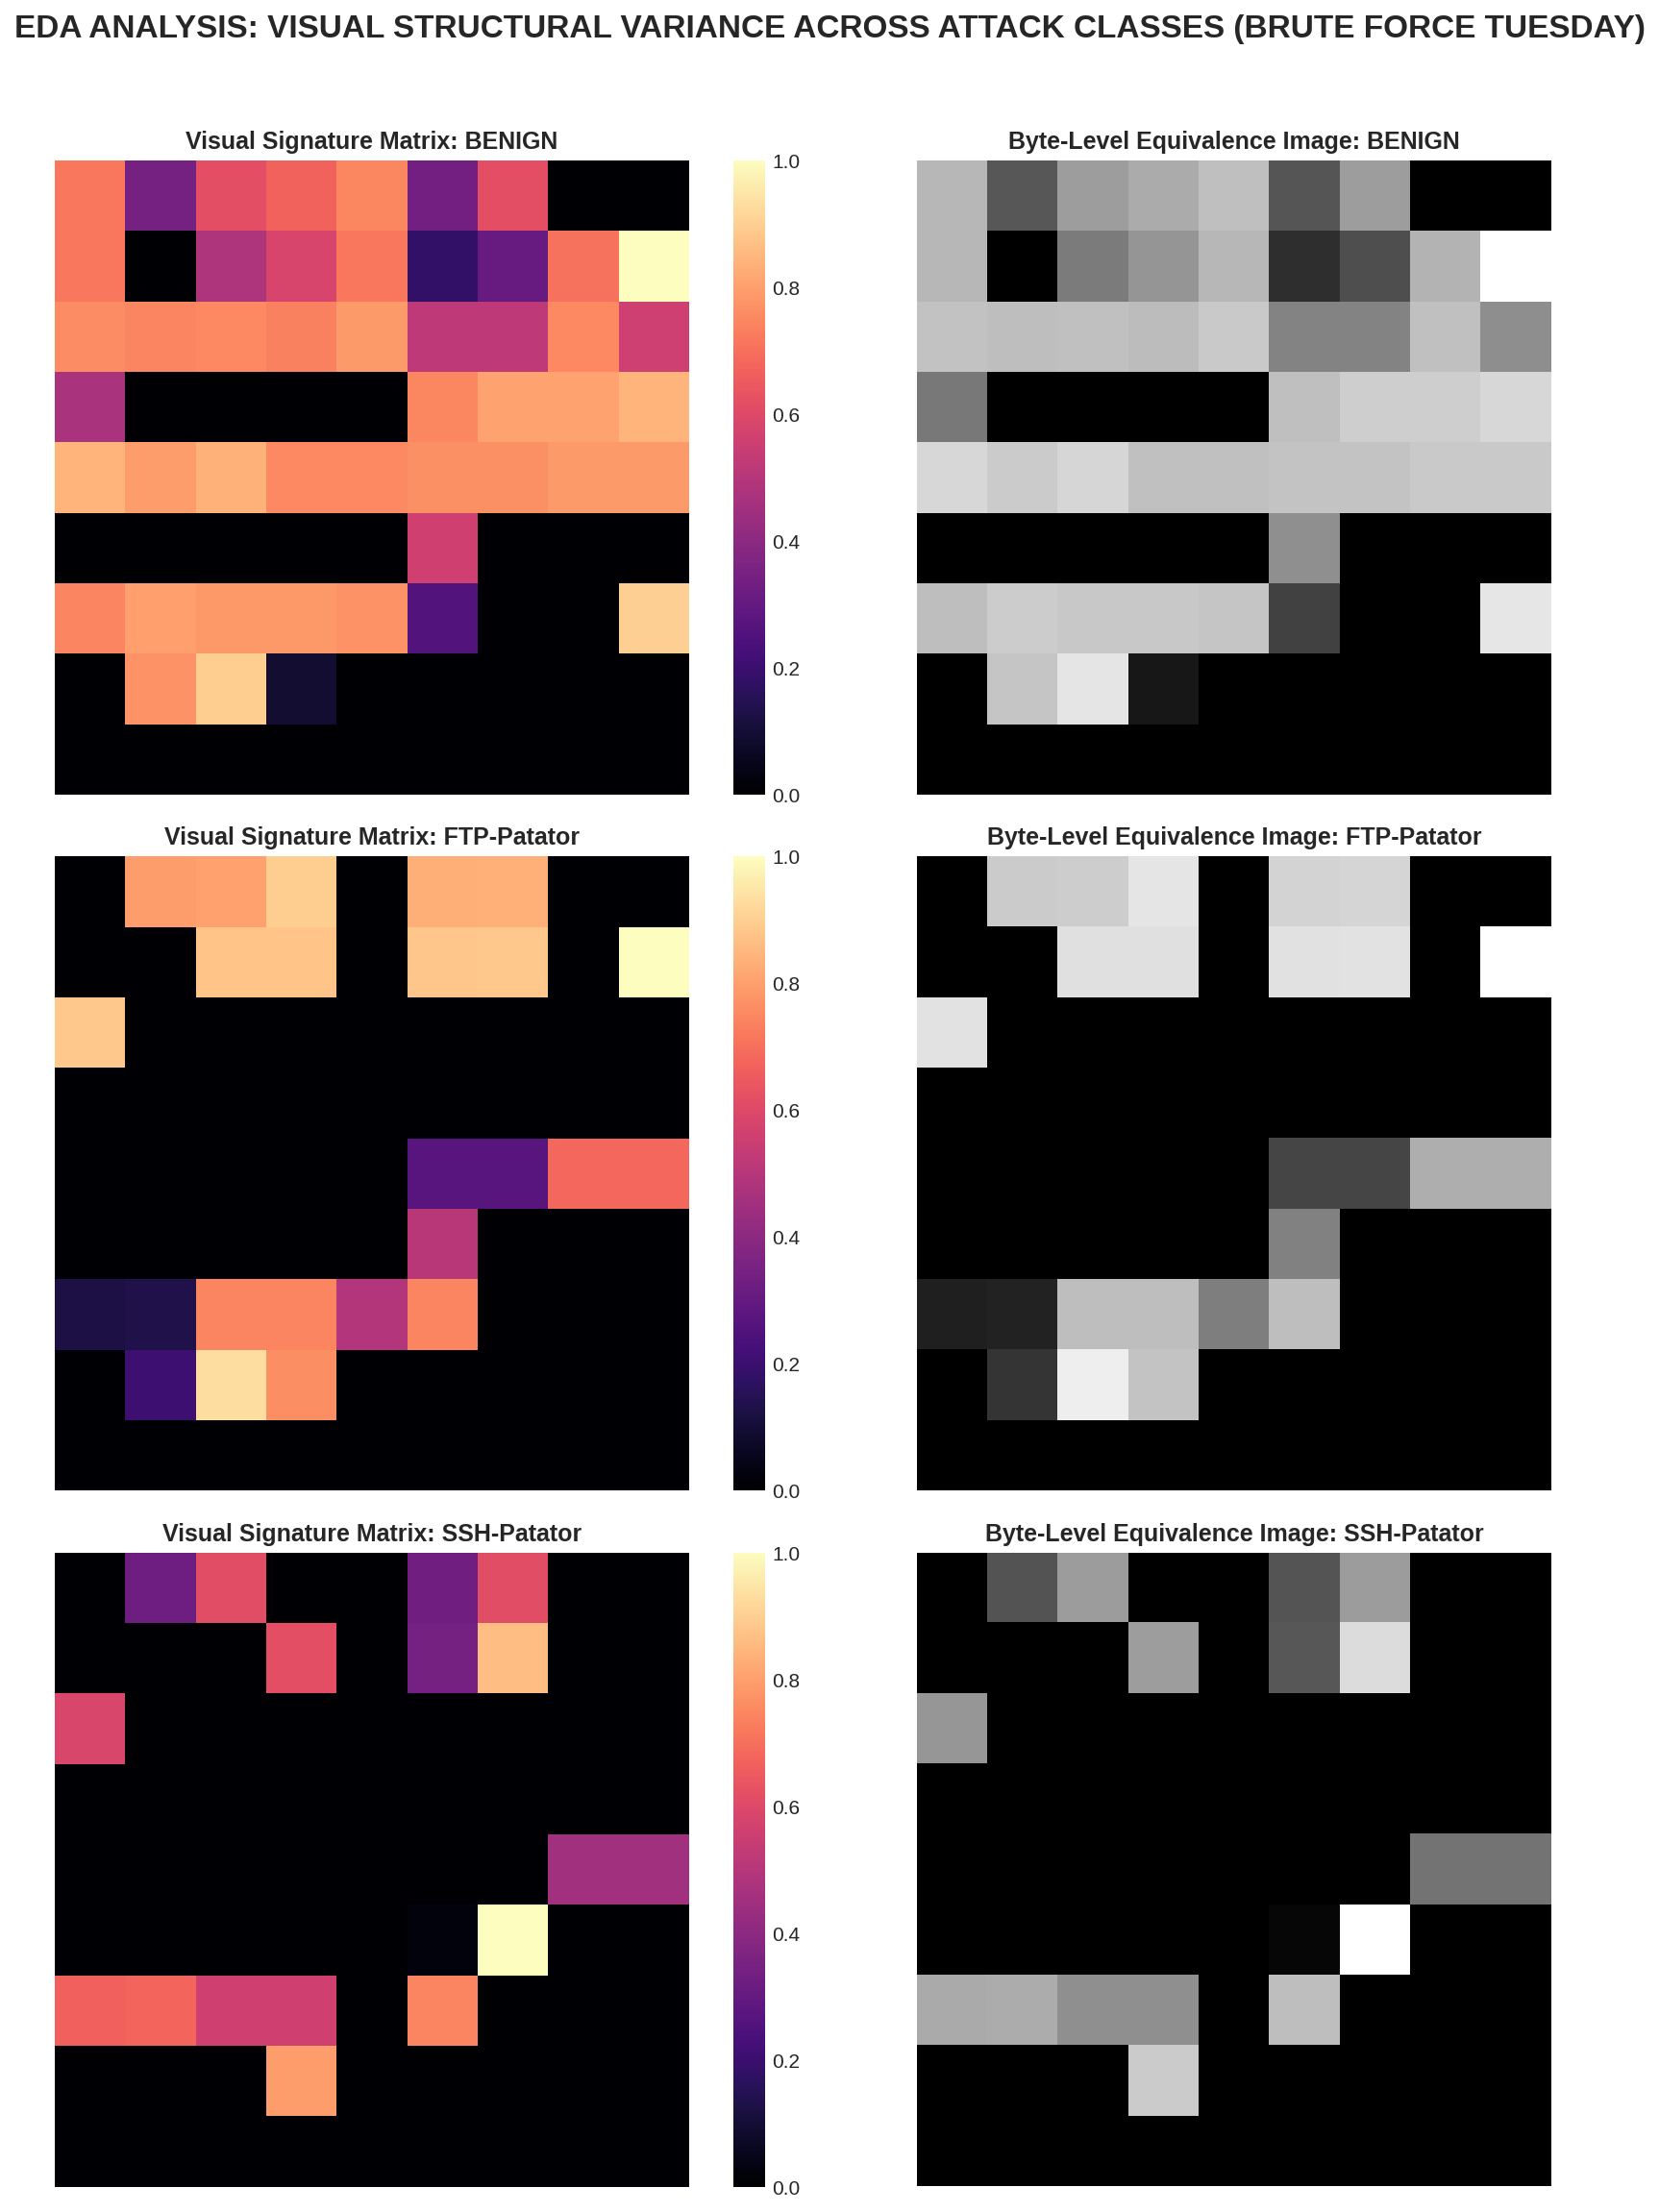

In [45]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (BRUTE FORCE TUESDAY)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


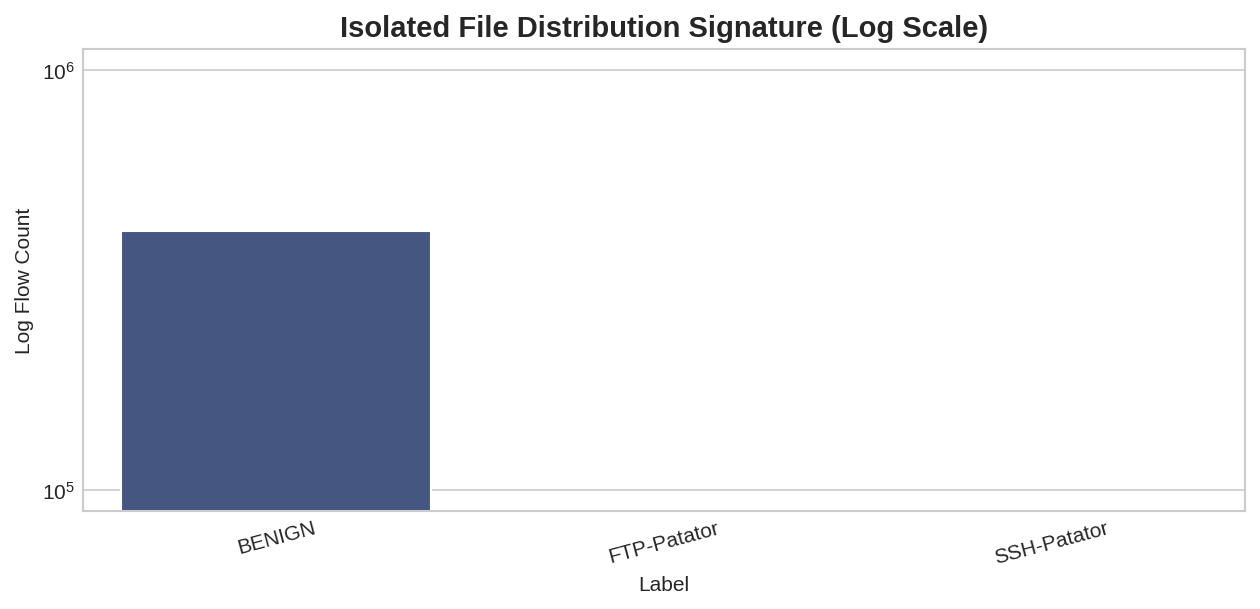

📝 Current Sub-split Frequency Index:
 🔹 BENIGN          : 412,692 flows (97.83%)
 🔹 FTP-Patator     : 5,933 flows (1.41%)
 🔹 SSH-Patator     : 3,219 flows (0.76%)


In [46]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print("📝 Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

📊 Generating Tuesday Brute Force file correlation matrix transformation graphics...


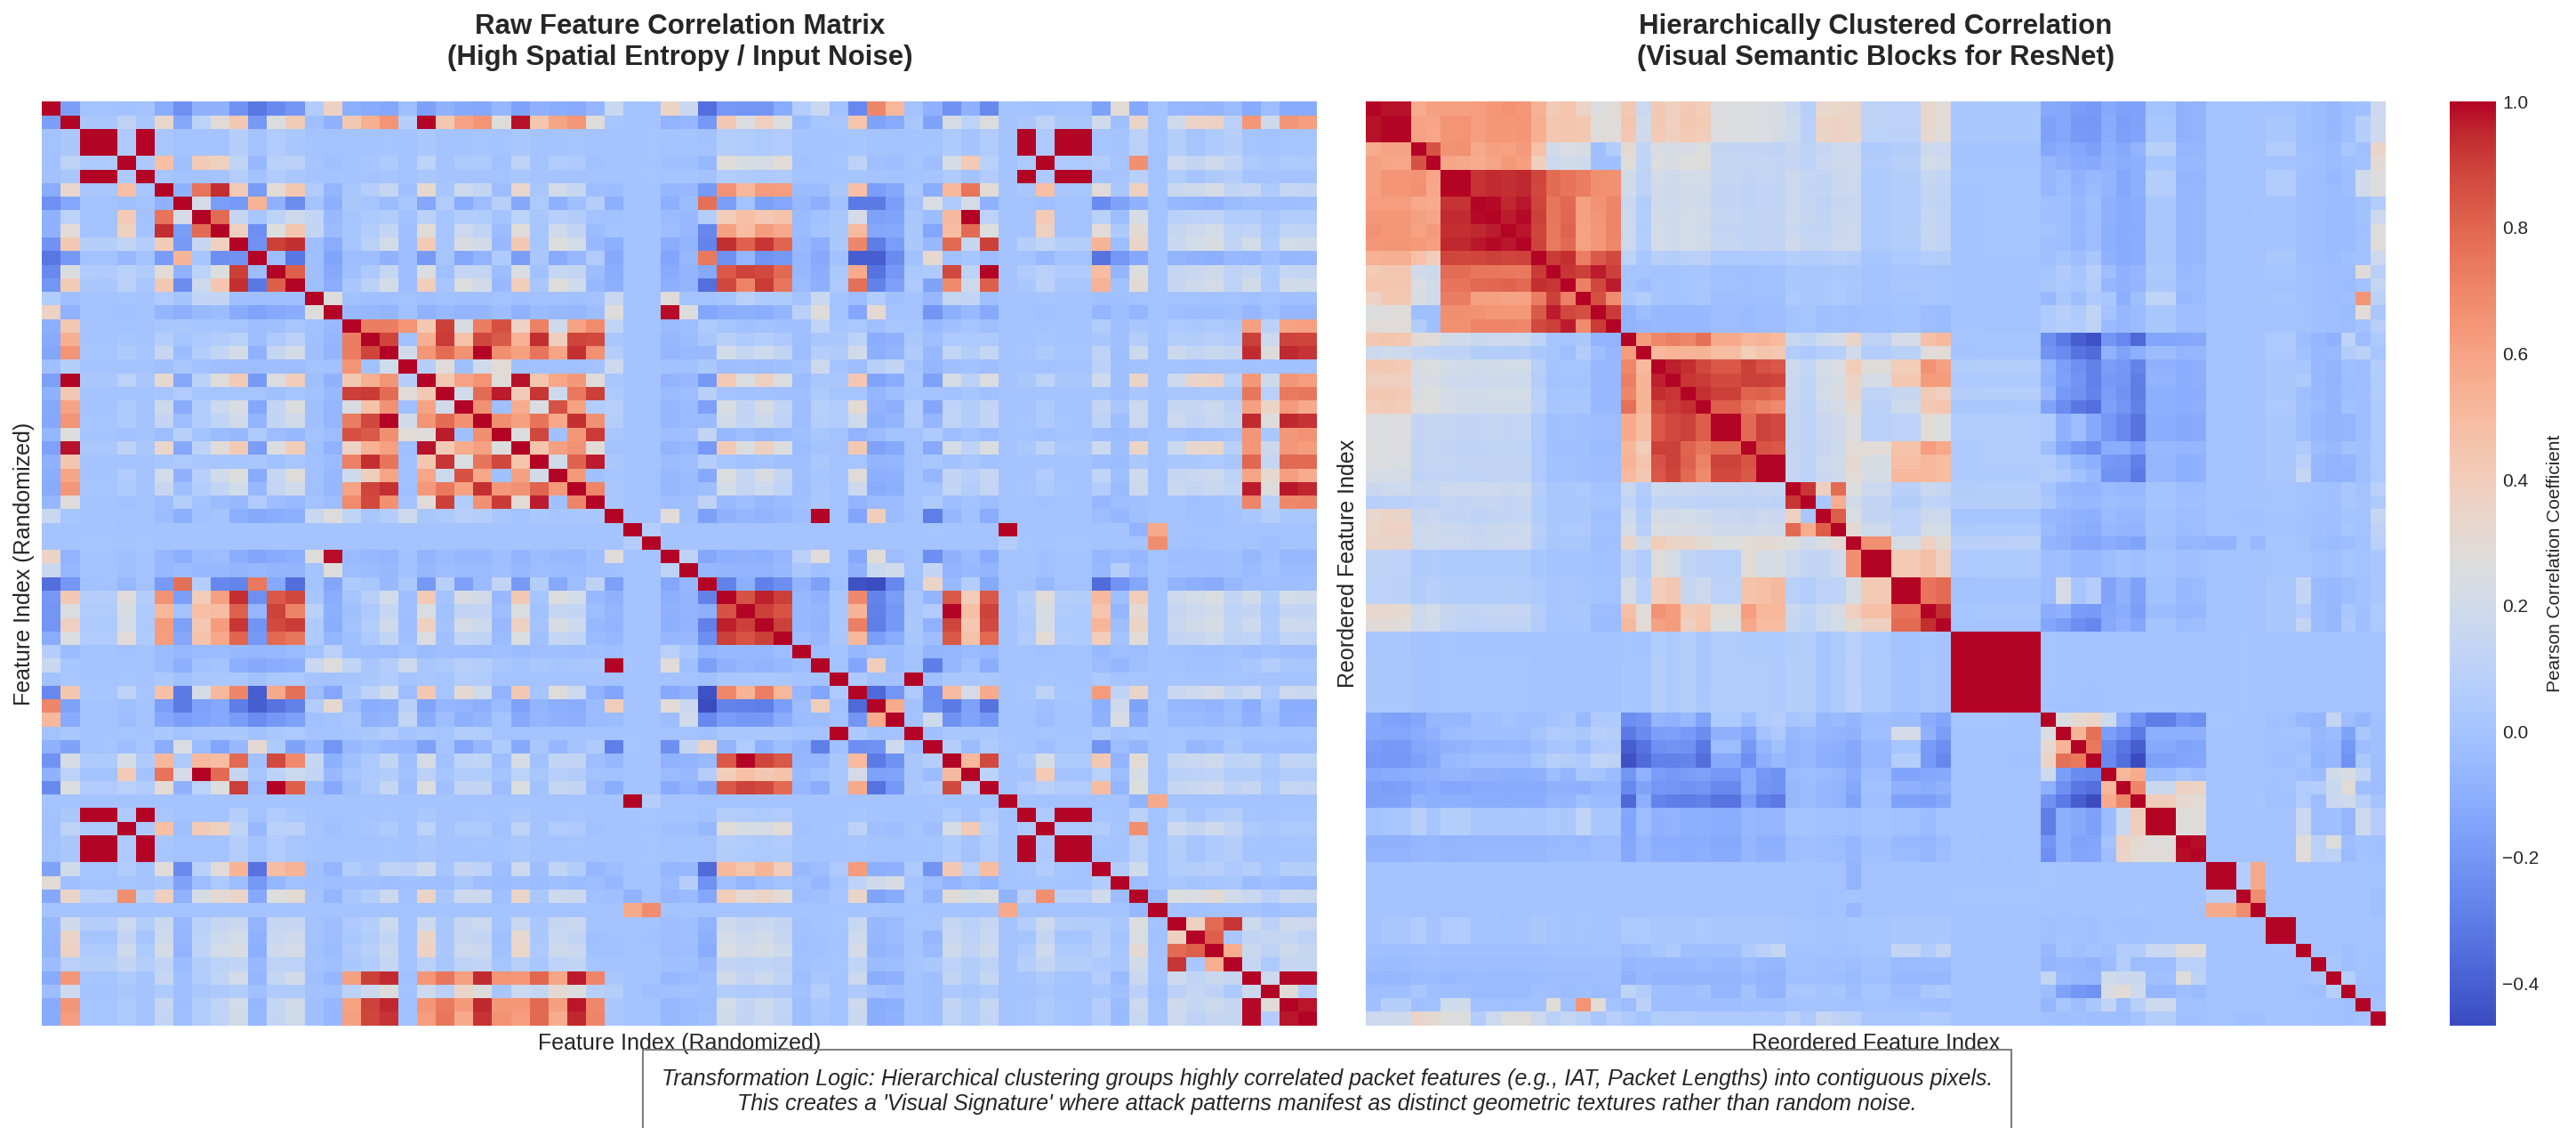

✅ Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


36455

In [47]:
print("📊 Generating Tuesday Brute Force file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"✅ Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()

 ----------8. Wednesday-workingHours.pcap_ISCX.csv----------

1. Targeted Data Loading & Robust Cleaning

In [48]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer
from scipy.cluster.hierarchy import linkage, leaves_list

# Setup Professional Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

# --- DATA SELECTION ENGINE ---
EXTRACT_PATH = '/content/cicids_data/MachineLearningCVE'
TARGET_FILE = 'Wednesday-workingHours.pcap_ISCX.csv'
FULL_PATH = os.path.join(EXTRACT_PATH, TARGET_FILE)

print(f"Isolation Protocol initiated for: {TARGET_FILE}")

# Streamlined ingestion
df = pd.read_csv(FULL_PATH)
df.columns = df.columns.str.strip() # Strip leading/trailing spaces in column headers

print(f"Raw Flow Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")

# 1. Clean Duplicates immediately to optimize RAM & prevent model over-indexing
df.drop_duplicates(inplace=True)

# 2. Neutralize Infinities & Nulls in Flow Rates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Label Standardization & Whitespace Sanitization
df['Label'] = df['Label'].str.strip()
# Standardize any internal typos matching raw dataset anomalies
df['Label'] = df['Label'].replace({
    'DoS Hulk': 'DoS Hulk',
    'DoS GoldenEye': 'DoS GoldenEye',
    'DoS slowloris': 'DoS slowloris',
    'DoS Slowhttptest': 'DoS Slowhttptest',
    'Heartbleed': 'Heartbleed'
})

print(f"Post-Sanitization Volume: {df.shape[0]:,} Unique Network Flows")
print(f"Target Ground Truths Available: {df['Label'].unique()}")

Isolation Protocol initiated for: Wednesday-workingHours.pcap_ISCX.csv
Raw Flow Shape: 692,703 Rows | 79 Columns
Post-Sanitization Volume: 610,794 Unique Network Flows
Target Ground Truths Available: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']


2. Zero-Variance Filtration & Hierarchical Space Sorting

In [49]:
# --- SPATIAL FEATURE ENGINEERING ---
X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number])

# Remove Constant / Zero Variance columns that provide zero visual variance
non_constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() > 1]
X_filtered = X_raw[non_constant_cols]

print(f"Dropped {X_raw.shape[1] - len(non_constant_cols)} zero-variance columns.")
print(f"Modeling {X_filtered.shape[1]} active structural dimensions into 2D space.")

# Hierarchical Cluster Logic for Topological Feature Ordering
print("Calculating topological feature groupings via Ward's Linkage...")
corr_matrix = X_filtered.corr().fillna(0).values
Z = linkage(corr_matrix, 'ward')
spatial_order = leaves_list(Z)

# Sort features topologically
ordered_features = X_filtered.columns[spatial_order]
print("Features mapped to continuous 1D spatial permutation string.")

Dropped 10 zero-variance columns.
Modeling 68 active structural dimensions into 2D space.
Calculating topological feature groupings via Ward's Linkage...
Features mapped to continuous 1D spatial permutation string.


3. Non-Linear Quantile Transformations & 9x9 Structural Formatting

In [50]:
# --- TRAFFIC-TO-IMAGE GENERATION PIPELINE ---

# Normalize distributions into uniform visual scale [0, 1] for optimal image contrast
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaled_vector = qt.fit_transform(X_filtered[ordered_features])

def generate_9x9_matrix(vector_data):
    """
    Transforms arbitrary feature vectors into a 9x9 structural image grid
    using trailing zero-padding to construct the 81-pixel signature frame.
    """
    # 9x9 matrix implies 81 distinct pixel bins
    padded_array = np.pad(vector_data, (0, 81 - len(vector_data)), 'constant', constant_values=0)
    return padded_array[:81].reshape(9, 9)

print("Image generation engine assembled successfully.")

Image generation engine assembled successfully.


4. Visual EDA & Pattern Discrimination Showroom

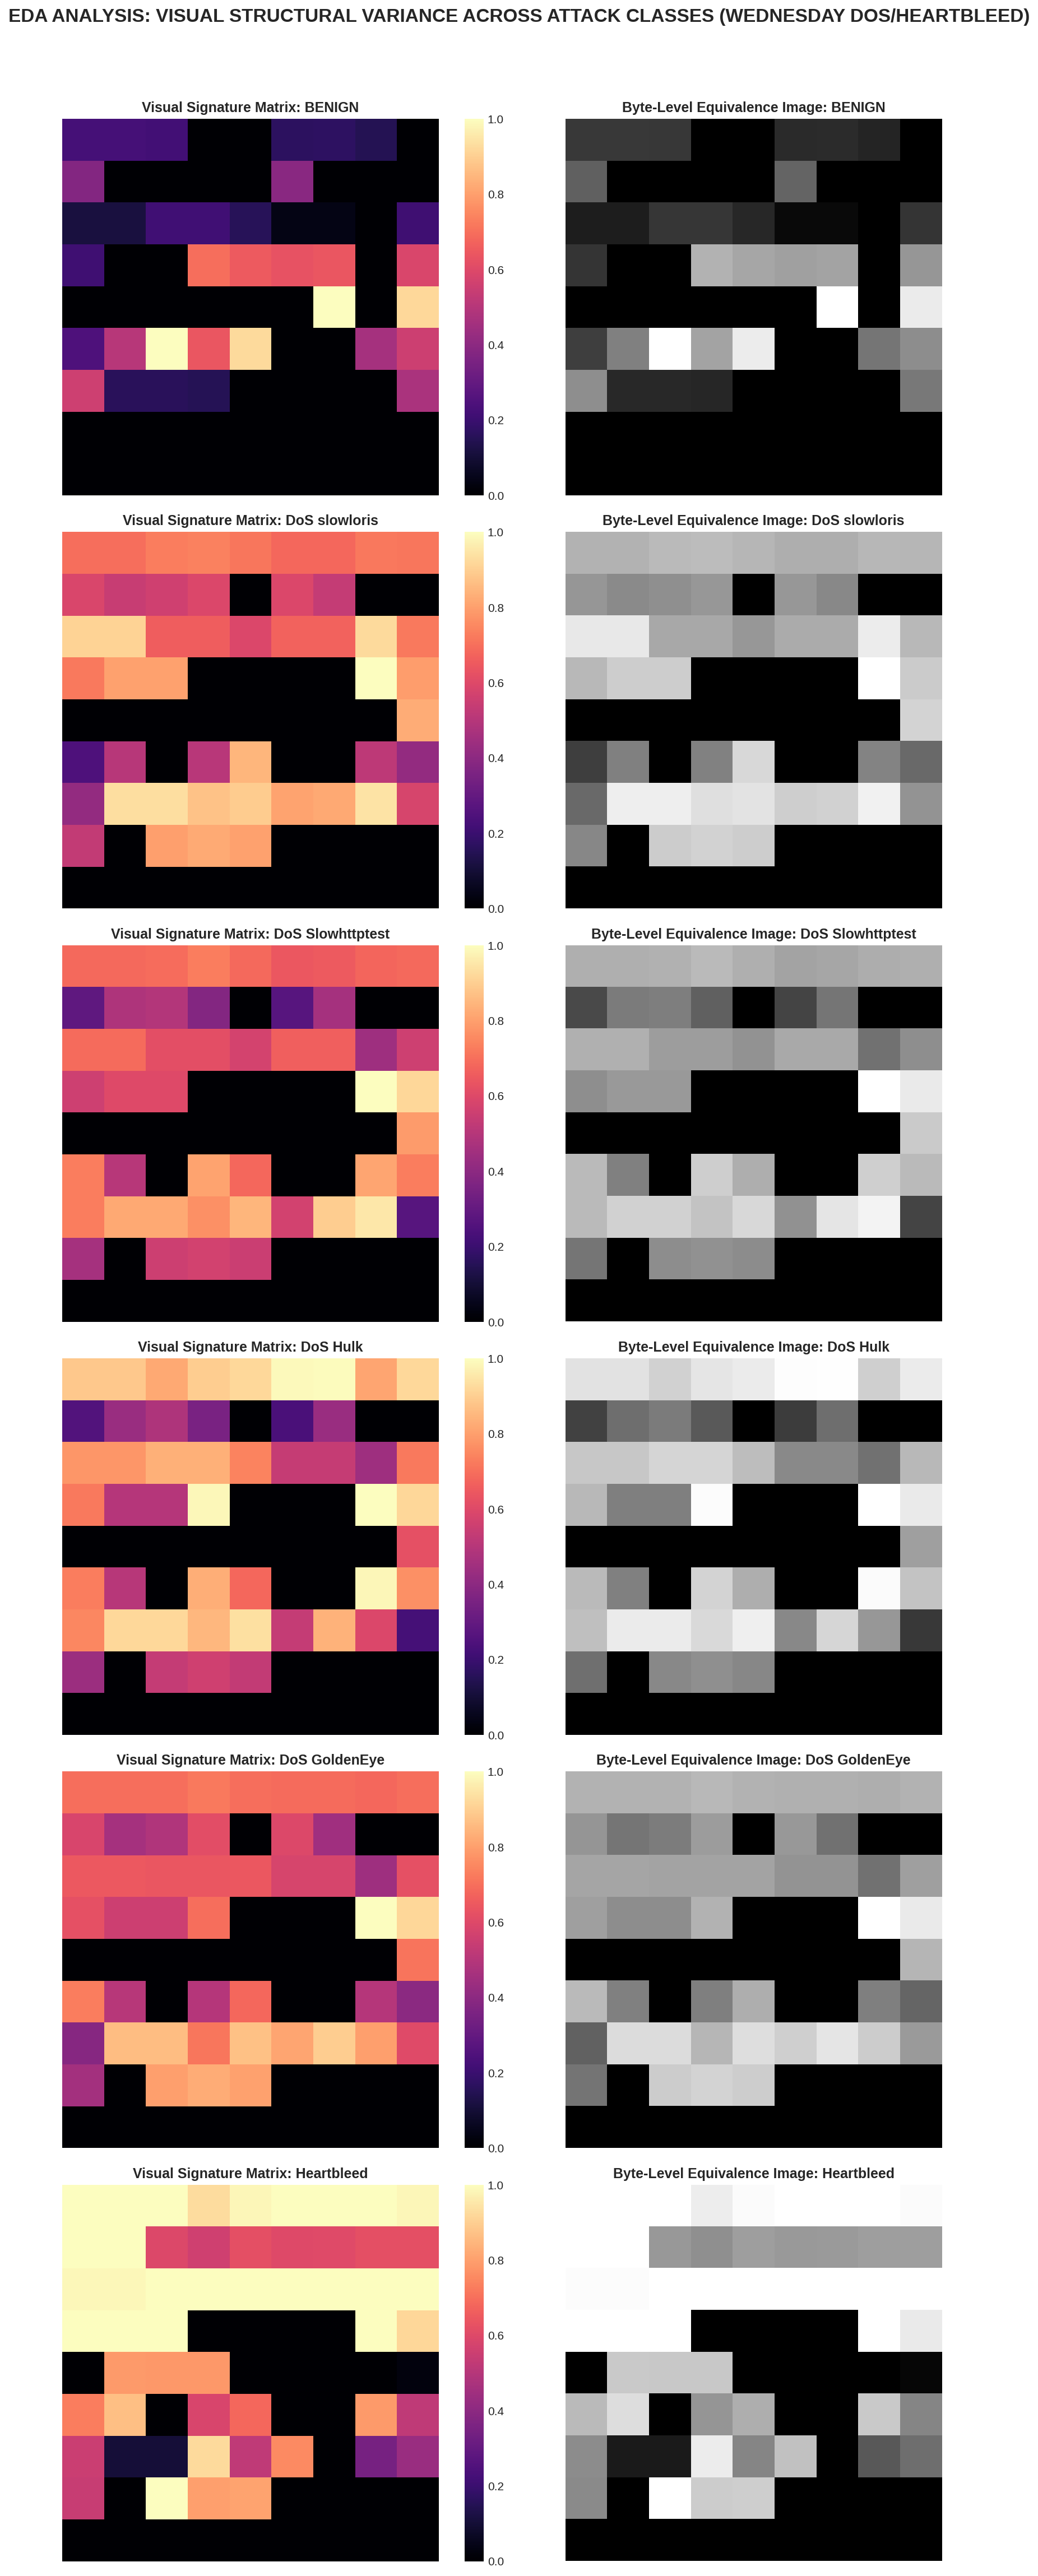

In [51]:
# --- VISUAL PATTERN EDA SHOWROOM ---
target_labels = df['Label'].unique()

fig, axes = plt.subplots(len(target_labels), 2, figsize=(12, 5 * len(target_labels)))

for idx, label_name in enumerate(target_labels):
    # Retrieve first logical slice containing target behavior
    sample_index = df[df['Label'] == label_name].index[0]
    raw_position = df.index.get_loc(sample_index)

    # Process signature array mapping
    pixel_grid = generate_9x9_matrix(scaled_vector[raw_position])

    # Render High-Contrast Heatmap Representation
    ax_heatmap = axes[idx, 0] if len(target_labels) > 1 else axes[0]
    sns.heatmap(pixel_grid, cmap='magma', cbar=True, ax=ax_heatmap, square=True, xticklabels=False, yticklabels=False)
    ax_heatmap.set_title(f"Visual Signature Matrix: {label_name}", fontweight='bold', fontsize=12)

    # Render Byte-Level Equivalent Representation
    ax_byte = axes[idx, 1] if len(target_labels) > 1 else axes[1]
    ax_byte.imshow(pixel_grid, cmap='gray', interpolation='nearest')
    ax_byte.set_title(f"Byte-Level Equivalence Image: {label_name}", fontweight='bold', fontsize=12)
    ax_byte.axis('off')

plt.suptitle("EDA ANALYSIS: VISUAL STRUCTURAL VARIANCE ACROSS ATTACK CLASSES (WEDNESDAY DOS/HEARTBLEED)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5. Multi-Class Target Distribution Audit

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


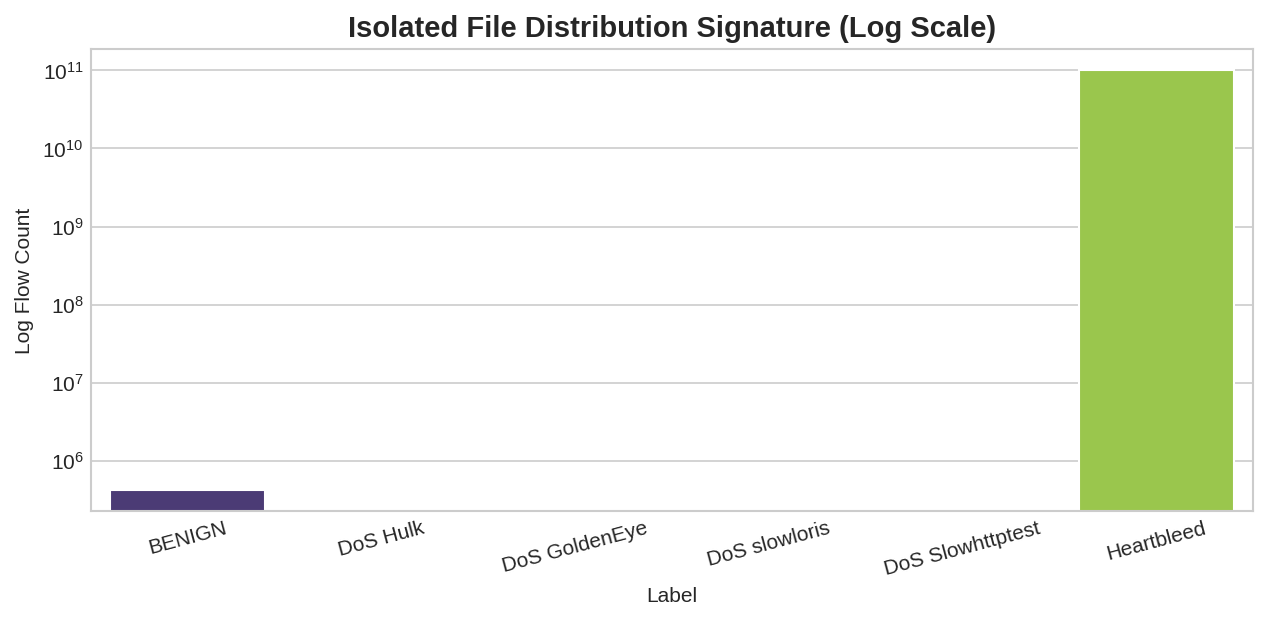

 Current Sub-split Frequency Index:
 🔹 BENIGN          : 417,035 flows (68.28%)
 🔹 DoS Hulk        : 172,849 flows (28.30%)
 🔹 DoS GoldenEye   : 10,286 flows (1.68%)
 🔹 DoS slowloris   : 5,385 flows (0.88%)
 🔹 DoS Slowhttptest : 5,228 flows (0.86%)
 🔹 Heartbleed      : 11 flows (0.00%)


In [54]:
# --- FINAL DISTRIBUTION INTEGRITY CHECK ---
plt.figure(figsize=(10, 4))
distribution_counts = df['Label'].value_counts()

sns.barplot(x=distribution_counts.index, y=distribution_counts.values, hue=distribution_counts.index, palette='viridis', log=True)
plt.title("Isolated File Distribution Signature (Log Scale)", fontweight='bold', fontsize=14)
plt.ylabel("Log Flow Count")
plt.xticks(rotation=15)
plt.show()

print(" Current Sub-split Frequency Index:")
for name, val in distribution_counts.items():
    print(f" 🔹 {name:<15} : {val:,} flows ({val/len(df):.2%})")

6. Spatial Reordering Verification (Dual-Correlation Heatmaps)

 Generating Wednesday DoS file correlation matrix transformation graphics...


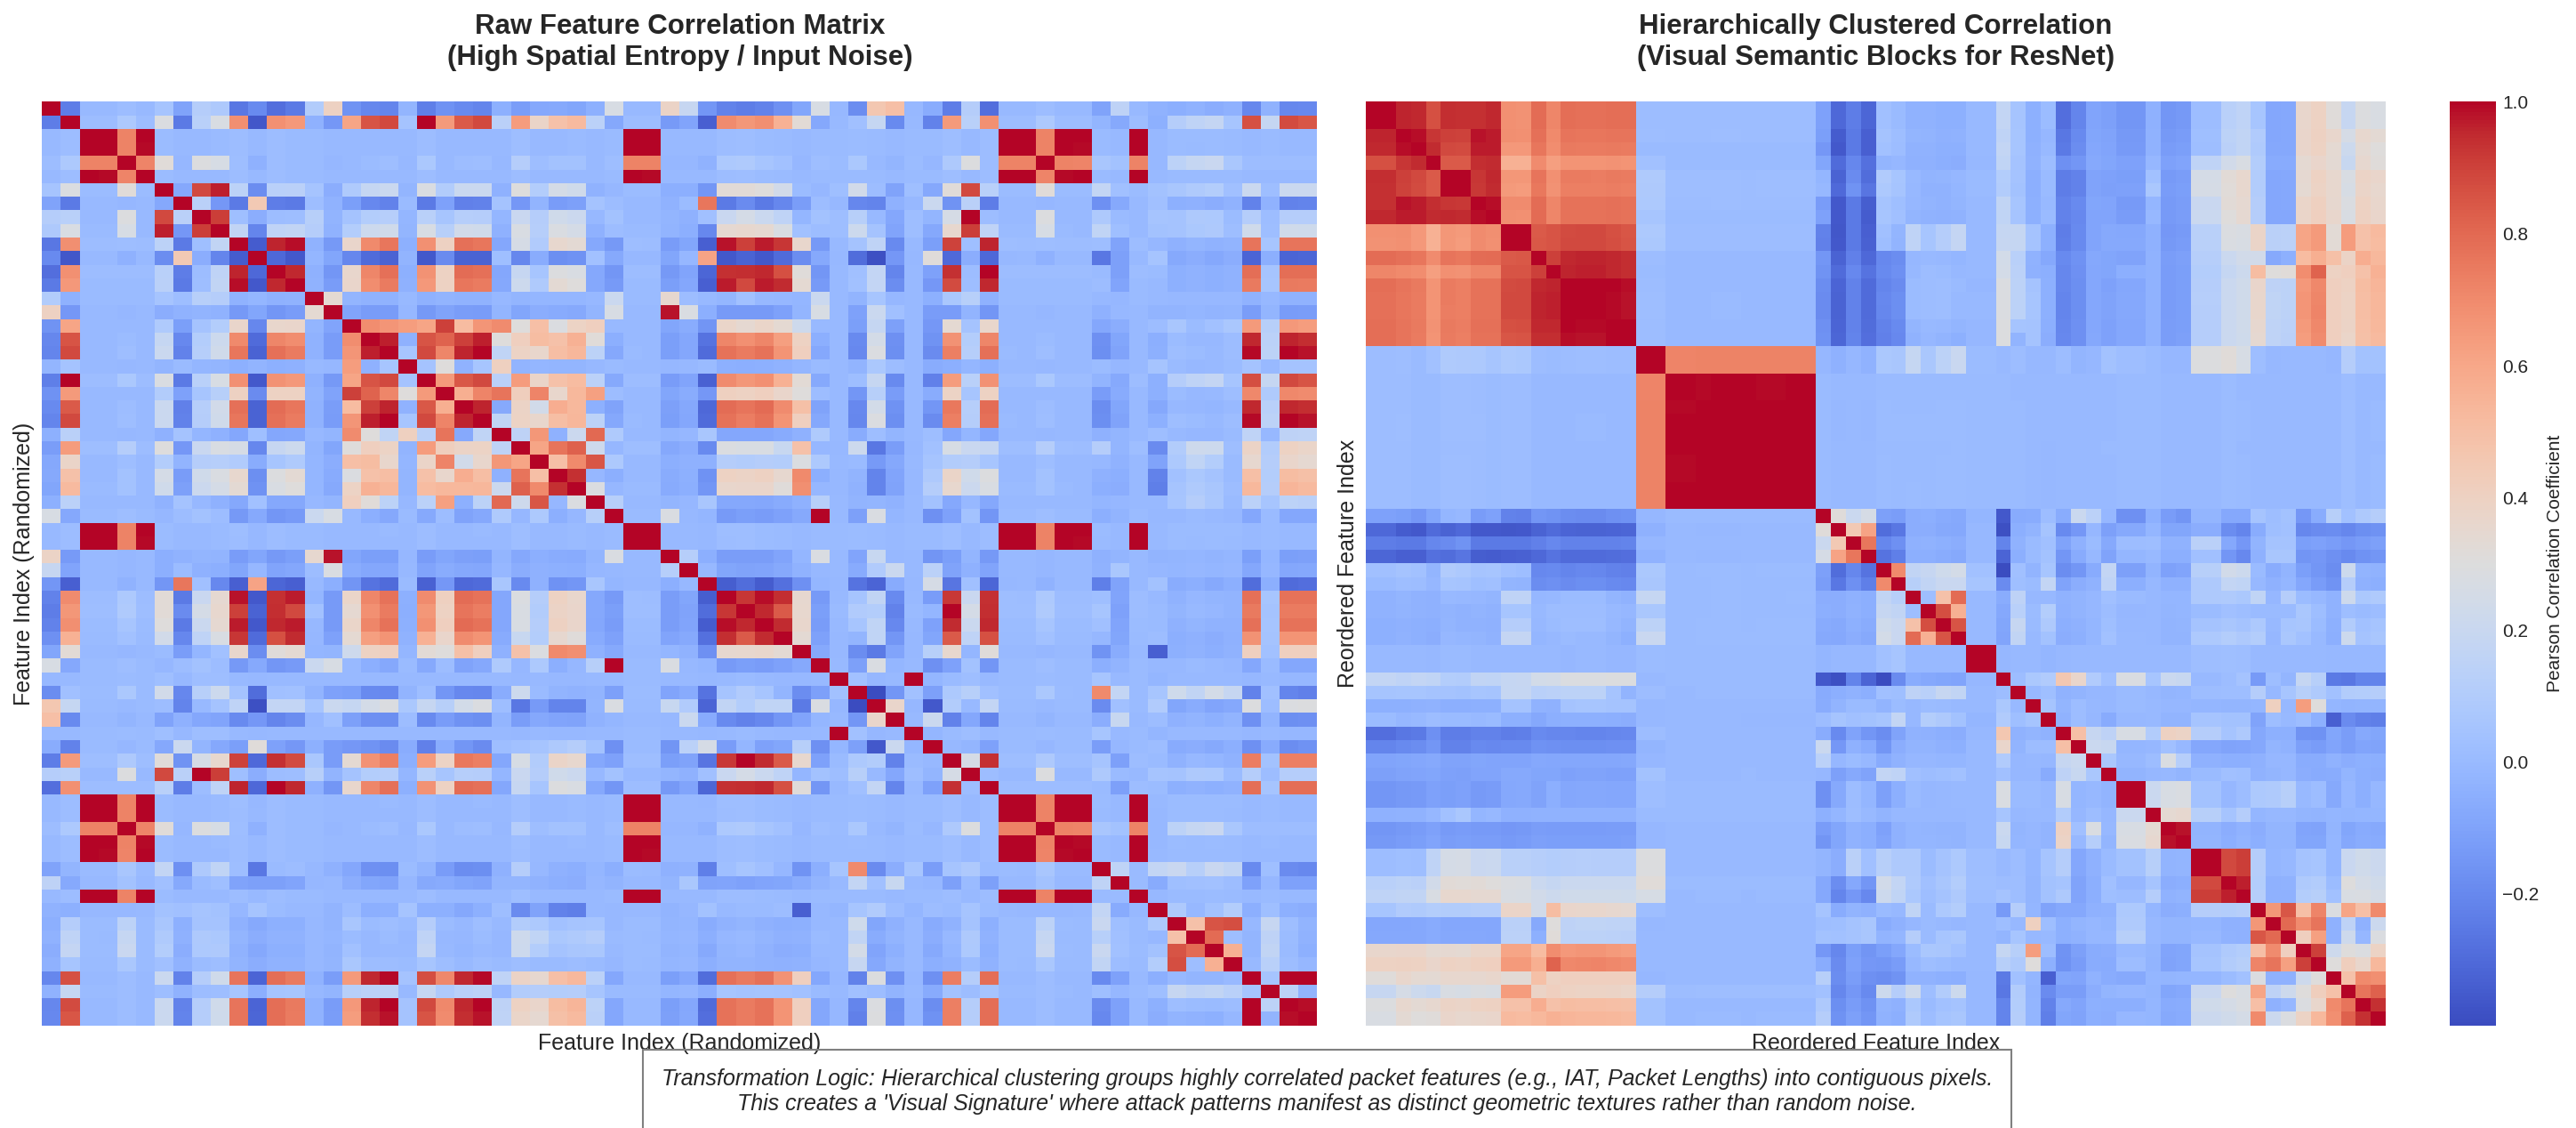

 Visualization complete. Reordering has successfully concentrated 68 features into dense visual structures.


7364

In [55]:
print(" Generating Wednesday DoS file correlation matrix transformation graphics...")

# Prepare matching clean scopes
original_features_df = X_filtered.copy()
ordered_features_df = X_filtered[ordered_features].copy()

original_corr = original_features_df.corr().fillna(0)
reordered_corr = ordered_features_df.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

# Plot Left Matrix
sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

# Plot Right Matrix
sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

# Legend caption insertion
fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features (e.g., IAT, Packet Lengths) into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f" Visualization complete. Reordering has successfully concentrated {len(X_filtered.columns)} features into dense visual structures.")

# Clean up local workspace memory safely
del original_features_df, ordered_features_df, original_corr, reordered_corr
gc.collect()